# NOTEBOOK MODELO

In [2]:
import tensorflow.compat.v1 as tf
tf.disable_eager_execution()

In [3]:
!pip install aif360

In [4]:
!pip install tensorflow==1.15

ERROR: Could not find a version that satisfies the requirement tensorflow==1.15 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==1.15


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import f_oneway

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.inprocessing import AdversarialDebiasing
import tensorflow as tf

from fairlearn.reductions import ExponentiatedGradient, DemographicParity

from itertools import product

import warnings
warnings.filterwarnings('ignore')

pip install 'aif360[inFairness]'


In [6]:
df_modelo = pd.read_csv(r'C:\Users\JAIME\Documents\Github\TFM-Sesgos-en-el-sistema-judicial-de-EEUU-\00_Data\00_Processed\df_modelo.csv')

In [7]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'priors_count', 'juv_priors_count', 'c_charge_degree', 'maritalstatus',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count',
       'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3', 'weight'],
      dtype='object')

## Nuestro Modelo v.1.0

In [8]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'priors_freq', 'priors_freq_2',
       'priors_freq_3', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'weight', 'sex']       #revisar una vez esté todo claro

In [9]:
lista_col_outliers = [
    'age',
    'priors_count',
    'juv_priors_count',
]

for col in lista_col_outliers:

    lower = df_modelo[col].quantile(0.01)
    upper = df_modelo[col].quantile(0.99)

    df_sin_outliers = df_modelo[
        (df_modelo[col] >= lower) &
        (df_modelo[col] <= upper)
    ]

Matriz de confusión:
[[548 233]
 [164 273]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       781
           1       0.54      0.62      0.58       437

    accuracy                           0.67      1218
   macro avg       0.65      0.66      0.66      1218
weighted avg       0.69      0.67      0.68      1218

ROC AUC: 0.7103886058183928
           Variable  Coeficiente
0               age    -0.042793
1      priors_count     0.152357
2  juv_priors_count     0.277740
3   c_charge_degree    -0.136428
Matriz de confusión:




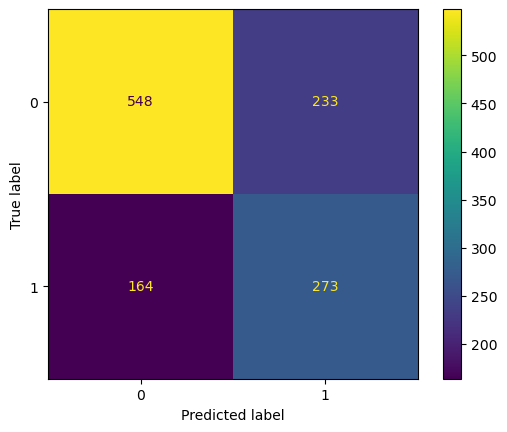

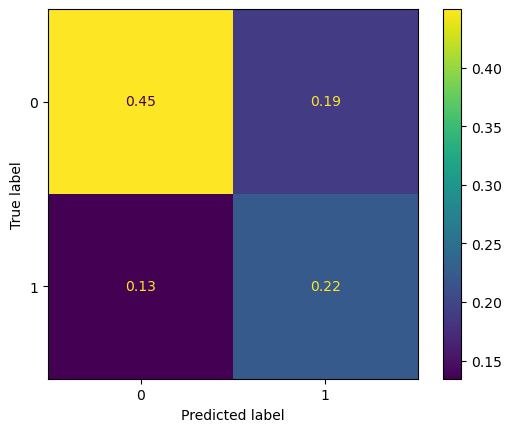

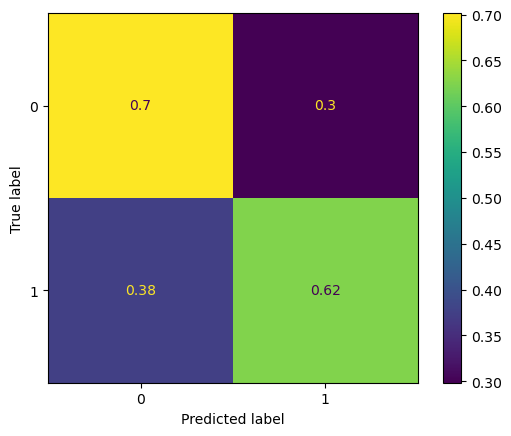



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       781
           1       0.54      0.62      0.58       437

    accuracy                           0.67      1218
   macro avg       0.65      0.66      0.66      1218
weighted avg       0.69      0.67      0.68      1218

ROC AUC: 0.7103886058183928


In [10]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 69, stratify = y)

# df_train = X_train.copy()
# df_train['two_year_recid'] = y_train
# w_train = df_train['weight']

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight='balanced')

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.515).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Matriz de confusión:




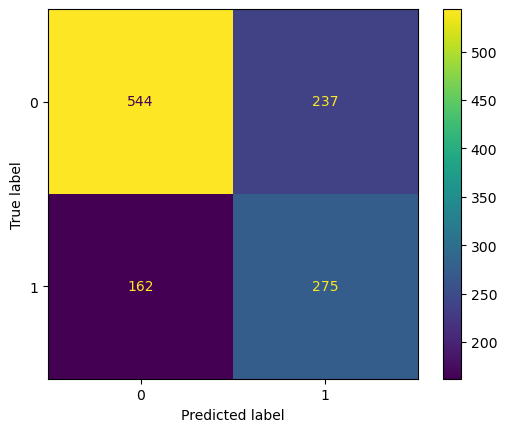

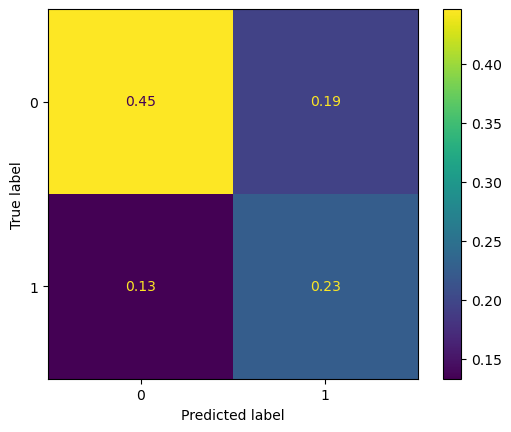

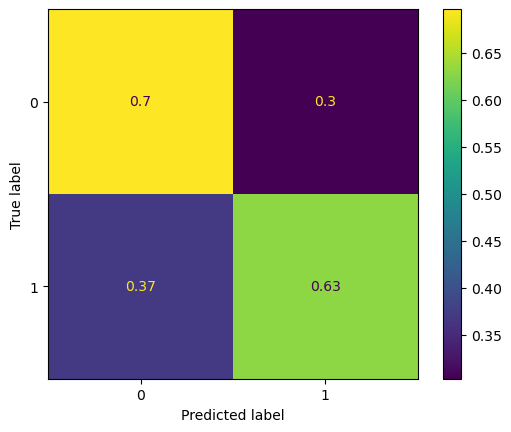



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       781
           1       0.54      0.63      0.58       437

    accuracy                           0.67      1218
   macro avg       0.65      0.66      0.66      1218
weighted avg       0.69      0.67      0.68      1218

ROC AUC: 0.7100252858946899


In [11]:
model = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear', class_weight = 'balanced'),
    n_estimators=10
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.515).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))



=== Raza: african-american ===


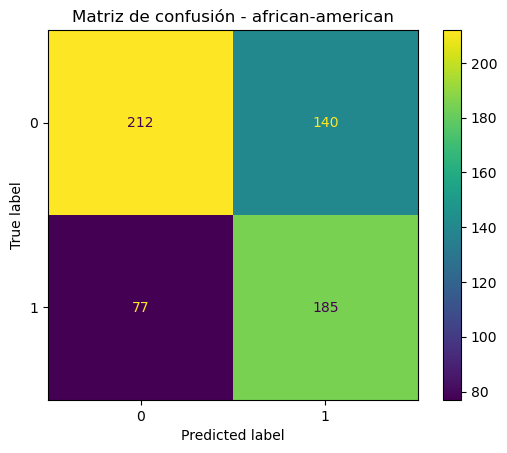

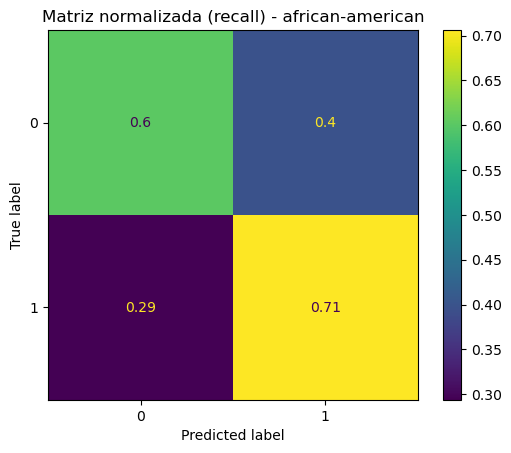


=== Raza: caucasian ===


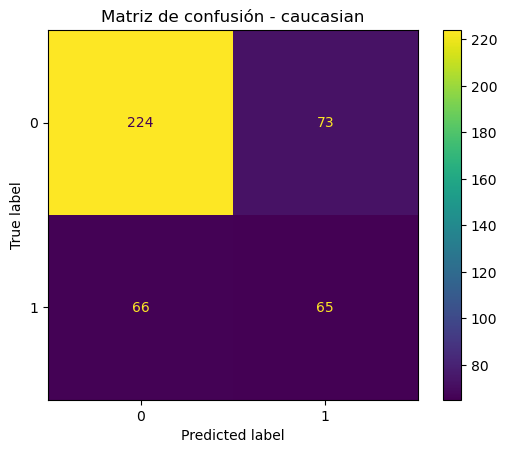

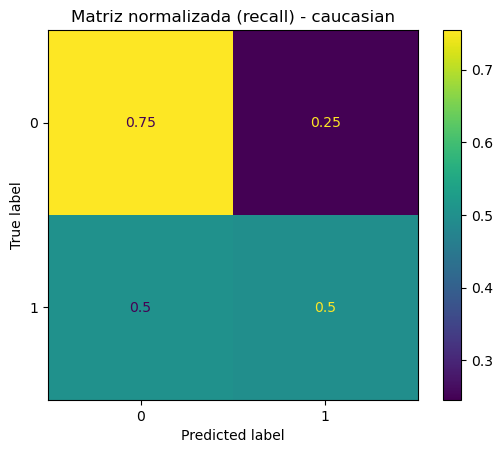


=== Raza: hispanic ===


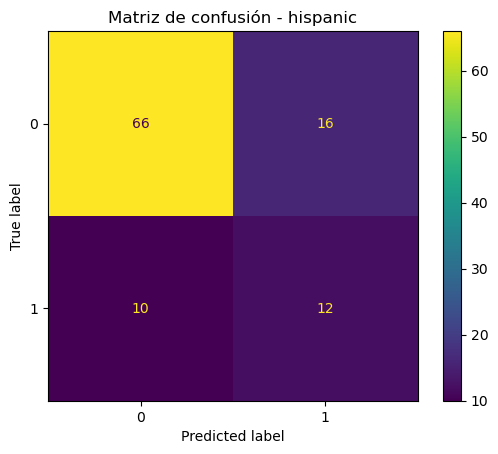

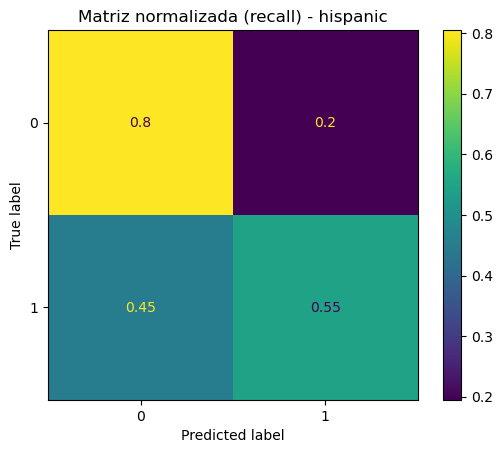


=== Raza: other ===


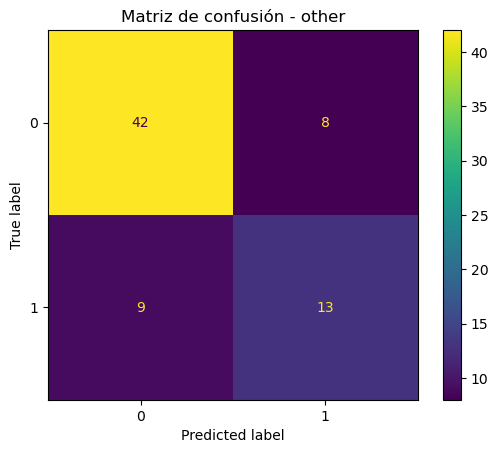

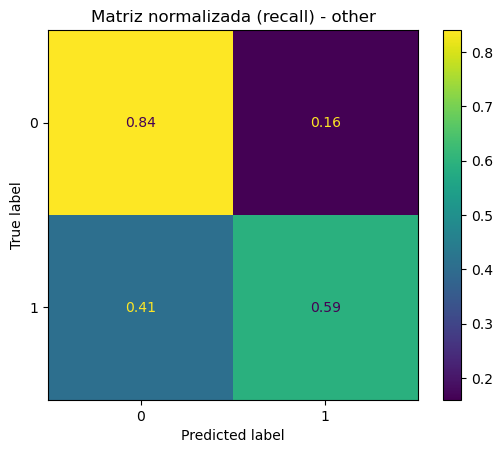

In [12]:
race_test = df_sin_outliers.loc[X_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

In [13]:
# Probar con priors_count en función de la edad (ej: 4 antecedentes en 4 años vs 10 antecedentes en 40 años)

## Modelo v.1.1

In [14]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'priors_count', 'juv_priors_count', 'c_charge_degree', 'maritalstatus',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count',
       'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3', 'weight'],
      dtype='object')

In [15]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'priors_freq', 'priors_freq_2',
       'priors_freq_3', 'weight', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex']

Matriz de confusión:
[[548 233]
 [164 273]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       781
           1       0.54      0.62      0.58       437

    accuracy                           0.67      1218
   macro avg       0.65      0.66      0.66      1218
weighted avg       0.69      0.67      0.68      1218

ROC AUC: 0.7103856758190081
           Variable  Coeficiente
0               age    -0.042771
1      priors_count     0.152348
2  juv_priors_count     0.277858
3   c_charge_degree    -0.136423
Matriz de confusión:




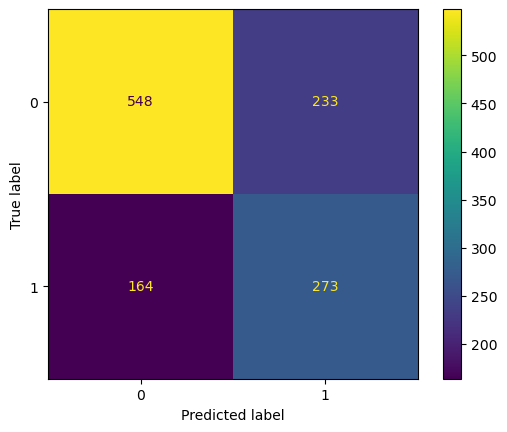

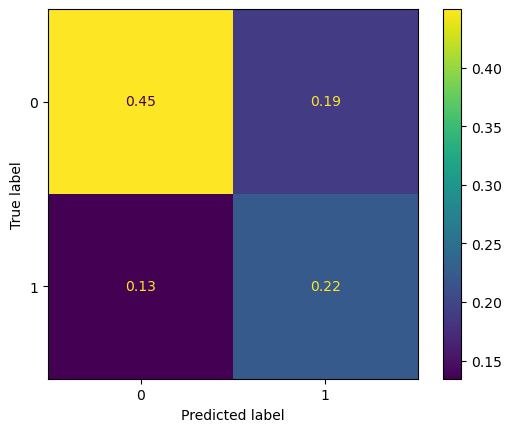

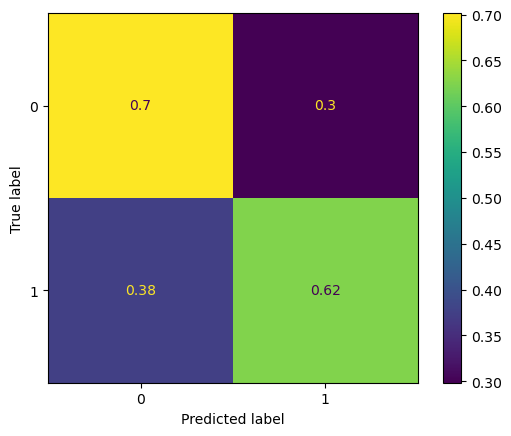



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       781
           1       0.54      0.62      0.58       437

    accuracy                           0.67      1218
   macro avg       0.65      0.66      0.66      1218
weighted avg       0.69      0.67      0.68      1218

ROC AUC: 0.7103856758190081

=== Raza: african-american ===


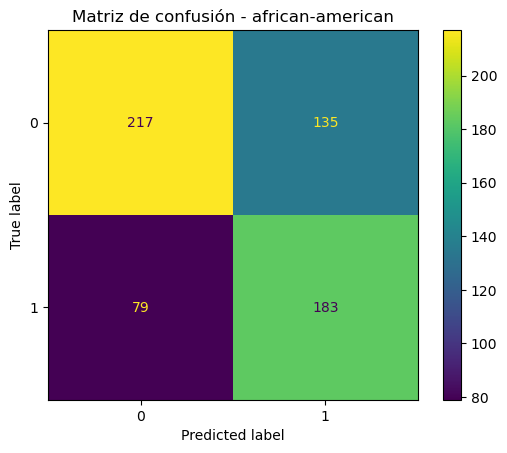

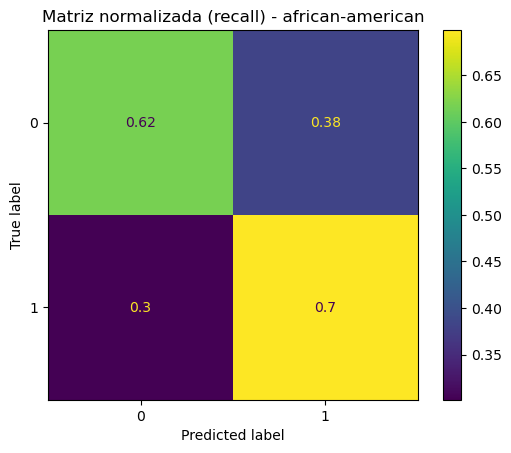


=== Raza: caucasian ===


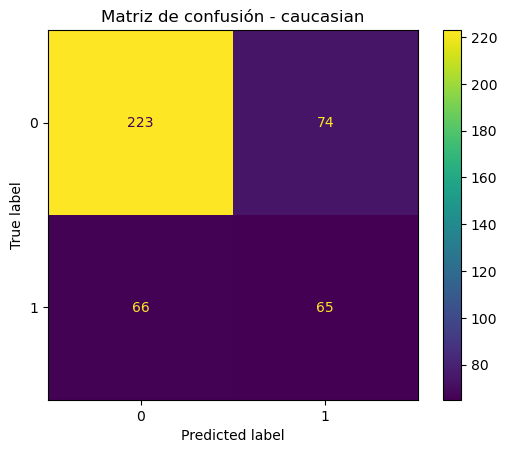

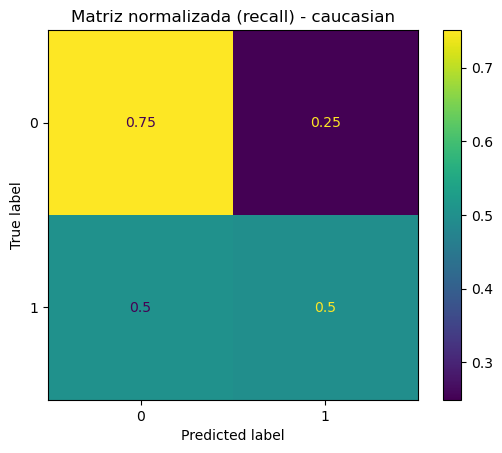


=== Raza: hispanic ===


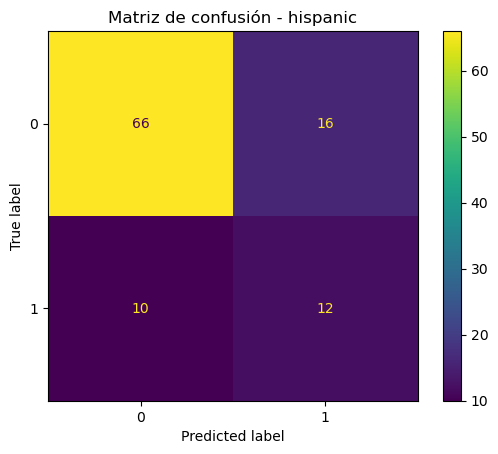

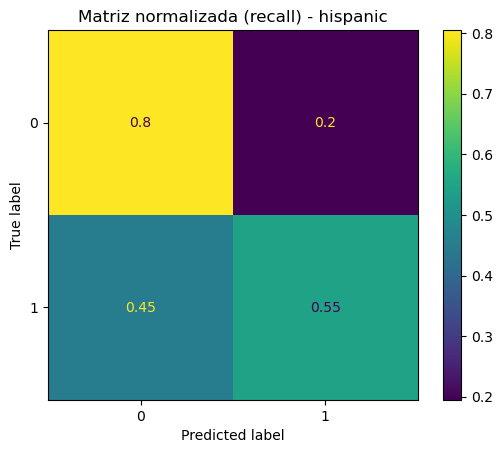


=== Raza: other ===


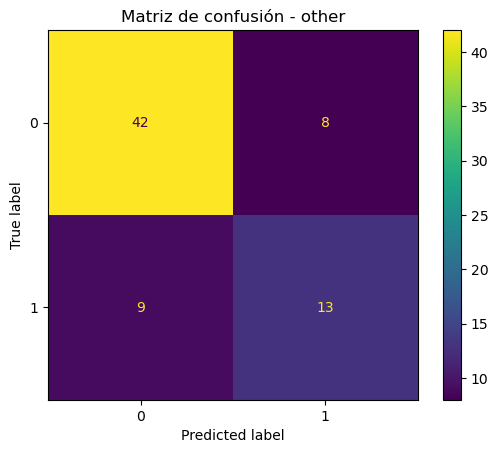

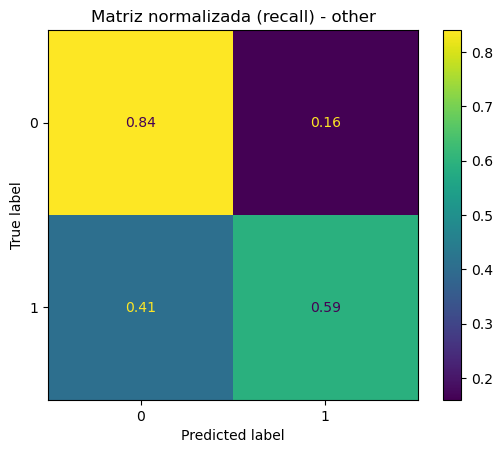

In [16]:
X1 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y1 = df_sin_outliers['two_year_recid']

X1_train, X1_test, y1_train, y1_test, = train_test_split(X1, y1, test_size = 0.2, random_state = 69, stratify = y1)

model1 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight='balanced')

model1.fit(X1_train, y1_train)

y1_proba = model1.predict_proba(X1_test)[:,1]
y1_pred = (y1_proba >= 0.515).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y1_test, y1_pred))
print("\nReporte de clasificación:")
print(classification_report(y1_test, y1_pred))
print("ROC AUC:", roc_auc_score(y1_test, y1_proba))

coeficientes = pd.DataFrame({
    'Variable': X1.columns,
    'Coeficiente': model1.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y1_test, y1_pred))
print("ROC AUC:", roc_auc_score(y1_test, y1_proba))

race_test = df_sin_outliers.loc[X1_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y1_test[idx]
    y_pred_r = y1_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

In [17]:
# model1 = BaggingClassifier(
#     estimator=LogisticRegression(penalty='l1', solver='liblinear'),
#     n_estimators=10
# )

# model1.fit(X1_train, y1_train, sample_weight = w1_train)

# y1_proba = model1.predict_proba(X1_test)[:,1]
# y1_pred = (y1_proba >= 0.37).astype(int)


# print("Matriz de confusión:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred))
# disp.plot()
# print("\n")
# disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "all"))
# disp.plot()
# disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "true"))
# disp.plot()
# plt.show()
# print("\n")
# print("Reporte de clasificación:")
# print(classification_report(y1_test, y1_pred))
# print("ROC AUC:", roc_auc_score(y1_test, y1_proba))


=== Raza: african-american ===


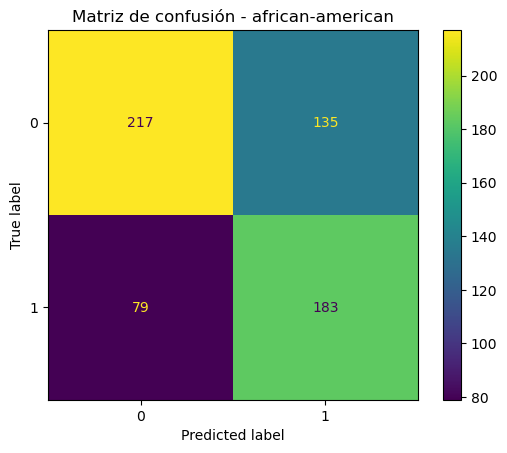

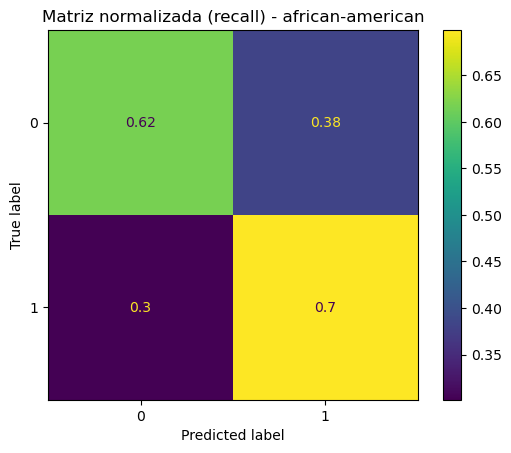


=== Raza: caucasian ===


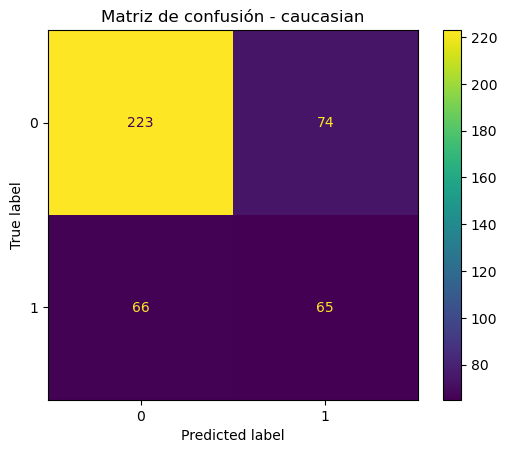

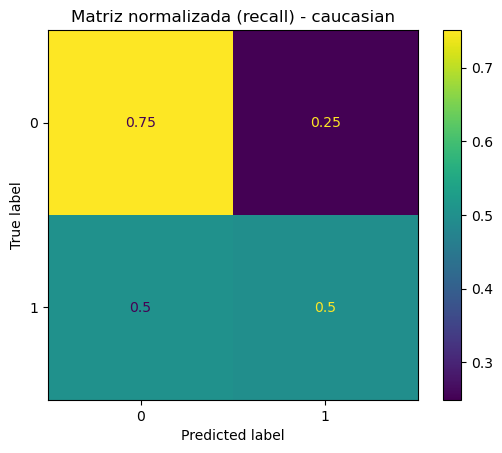


=== Raza: hispanic ===


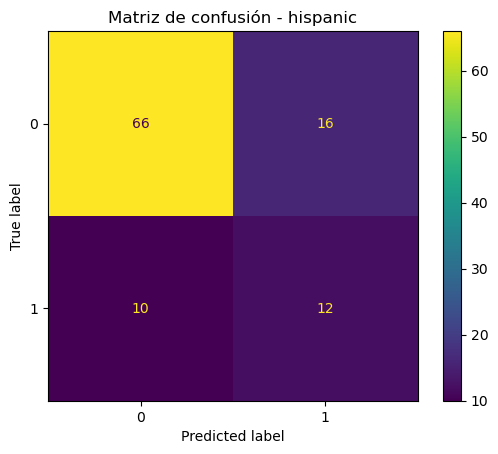

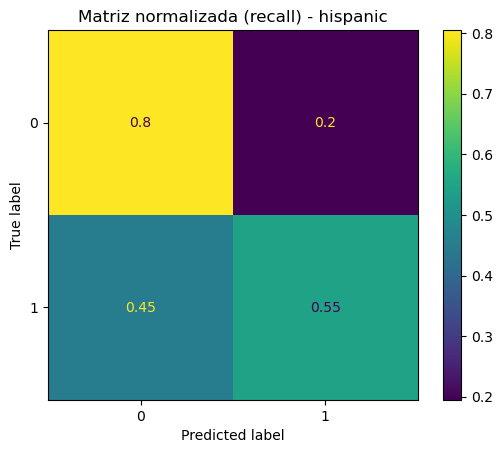


=== Raza: other ===


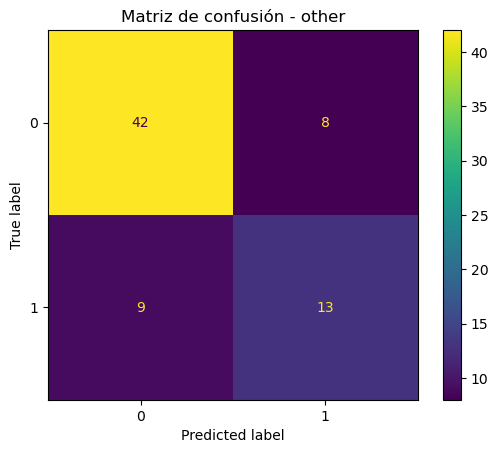

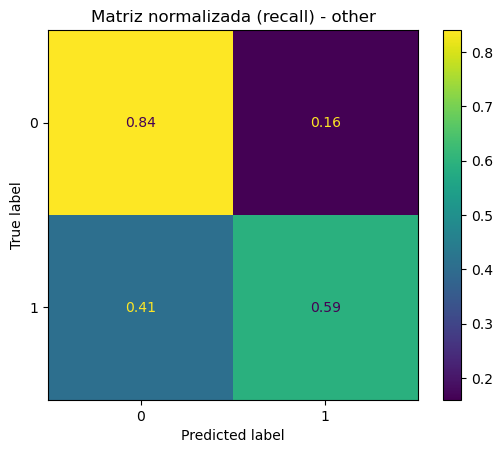

In [18]:
race_test = df_sin_outliers.loc[X1_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y1_test[idx]
    y_pred_r = y1_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

## Modelo v.1.2

In [19]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'priors_count', 'juv_priors_count', 'c_charge_degree', 'maritalstatus',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count',
       'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3', 'weight'],
      dtype='object')

In [20]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'priors_freq',
       'priors_freq_2', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'weight', 'priors_count', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other']

Matriz de confusión:
[[539 242]
 [169 268]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72       781
           1       0.53      0.61      0.57       437

    accuracy                           0.66      1218
   macro avg       0.64      0.65      0.64      1218
weighted avg       0.68      0.66      0.67      1218

ROC AUC: 0.7149403598625244
           Variable  Coeficiente
0               sex    -0.349124
1               age    -0.018493
2  juv_priors_count     0.144627
3   c_charge_degree    -0.125963
4     priors_freq_3     3.520880
Matriz de confusión:




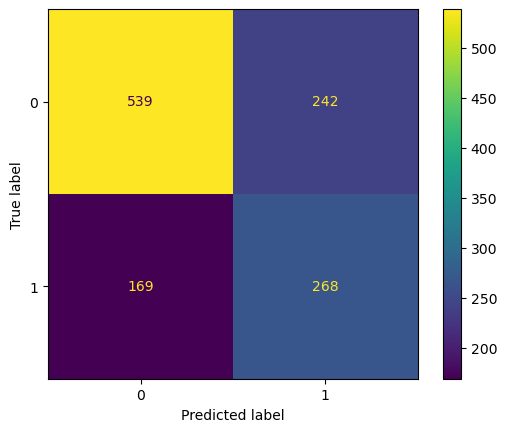

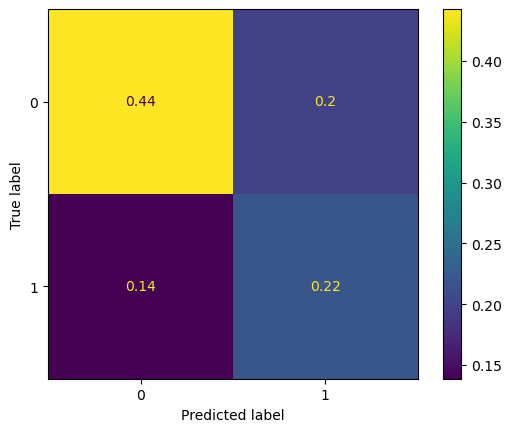

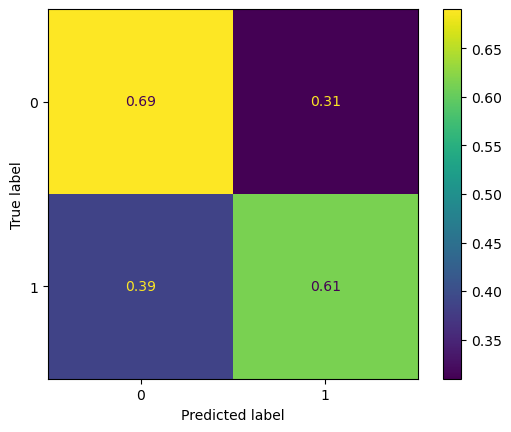



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72       781
           1       0.53      0.61      0.57       437

    accuracy                           0.66      1218
   macro avg       0.64      0.65      0.64      1218
weighted avg       0.68      0.66      0.67      1218

ROC AUC: 0.7149403598625244


In [21]:
X2 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y2 = df_sin_outliers['two_year_recid']

X2_train, X2_test, y2_train, y2_test= train_test_split(X2, y2, test_size = 0.2, random_state = 69, stratify = y2)

model2 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight='balanced')

model2.fit(X2_train, y2_train)

y2_proba = model2.predict_proba(X2_test)[:,1]
y2_pred = (y2_proba >= 0.495).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y2_test, y2_pred))
print("\nReporte de clasificación:")
print(classification_report(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba))

coeficientes = pd.DataFrame({
    'Variable': X2.columns,
    'Coeficiente': model2.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba))

In [22]:
# model2 = BaggingClassifier(
#     estimator=LogisticRegression(penalty='l1', solver='liblinear'),
#     n_estimators=10
# )

# model2.fit(X2_train, y2_train, sample_weight=w2_train)

# y2_proba = model2.predict_proba(X2_test)[:,1]
# y2_pred = (y2_proba >= 0.37).astype(int)


# print("Matriz de confusión:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred))
# disp.plot()
# print("\n")
# disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "all"))
# disp.plot()
# disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "true"))
# disp.plot()
# plt.show()
# print("\n")
# print("Reporte de clasificación:")
# print(classification_report(y2_test, y2_pred))
# print("ROC AUC:", roc_auc_score(y2_test, y2_proba))


=== Raza: african-american ===


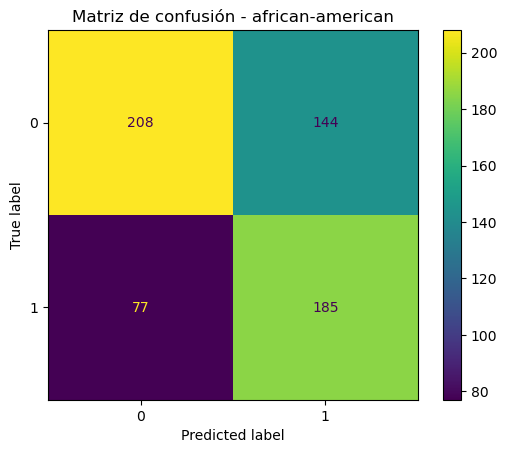

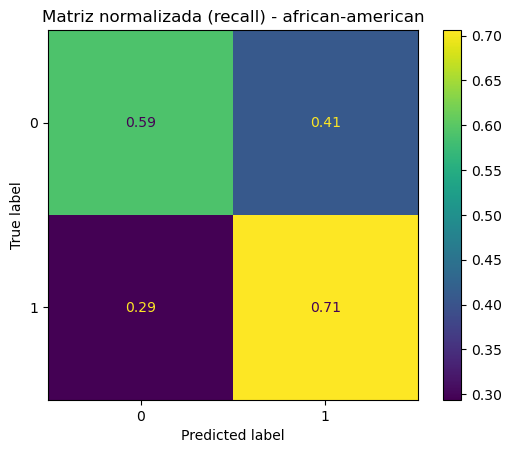


=== Raza: caucasian ===


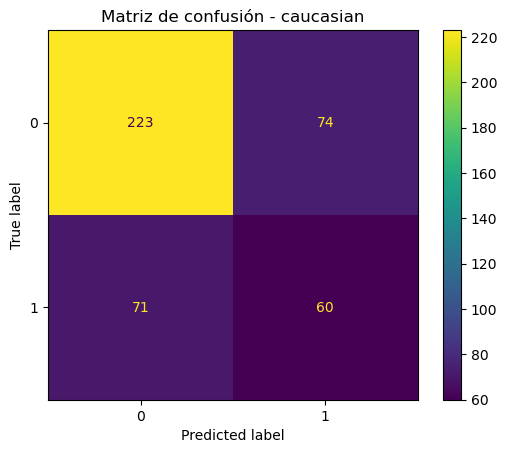

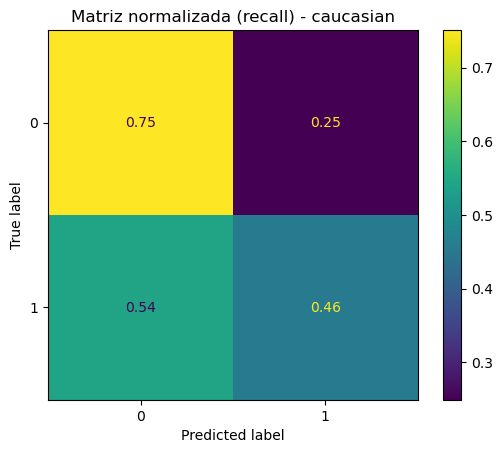


=== Raza: hispanic ===


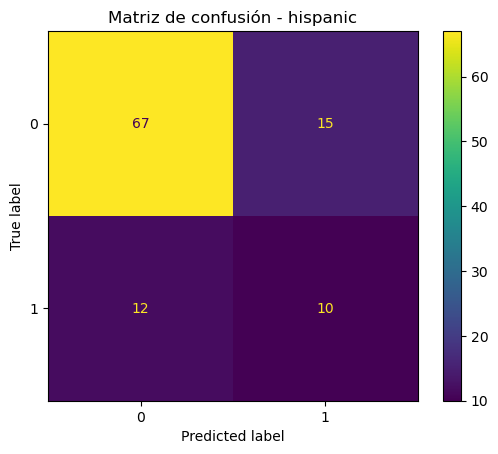

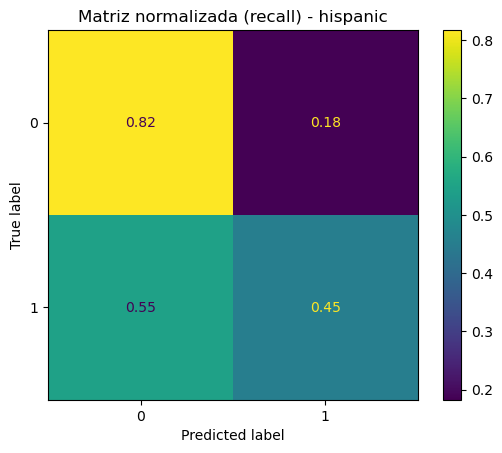


=== Raza: other ===


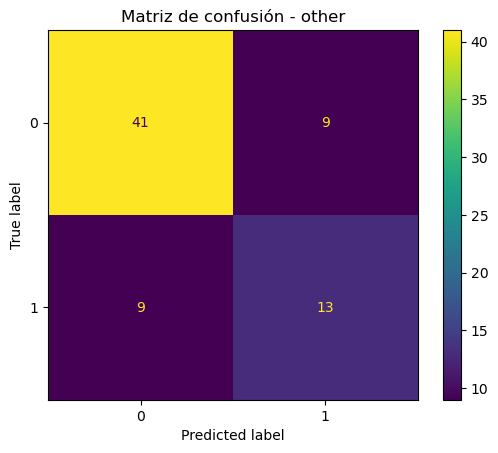

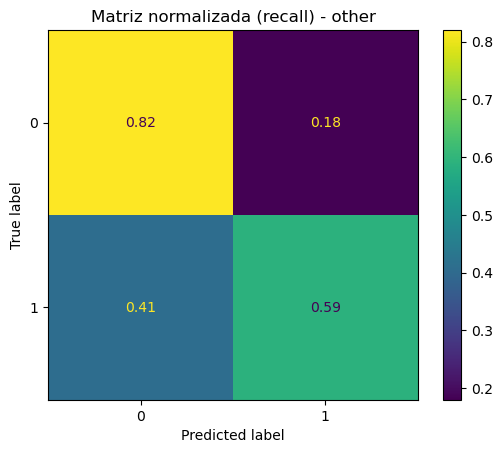

In [23]:
race_test = df_sin_outliers.loc[X2_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y2_test[idx]
    y_pred_r = y2_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

## Modelo v1.3

In [24]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'priors_count', 'juv_priors_count', 'c_charge_degree', 'maritalstatus',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count',
       'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3', 'weight'],
      dtype='object')

In [25]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race',
       'priors_freq_3', 'priors_freq', 'priors_count', 'sex', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'weight', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other']

Matriz de confusión:
[[556 225]
 [172 265]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       781
           1       0.54      0.61      0.57       437

    accuracy                           0.67      1218
   macro avg       0.65      0.66      0.65      1218
weighted avg       0.68      0.67      0.68      1218

ROC AUC: 0.7117012455427384
           Variable  Coeficiente
0               age    -0.017274
1  juv_priors_count     0.200220
2   c_charge_degree    -0.131303
3     priors_freq_2     5.824140
Matriz de confusión:




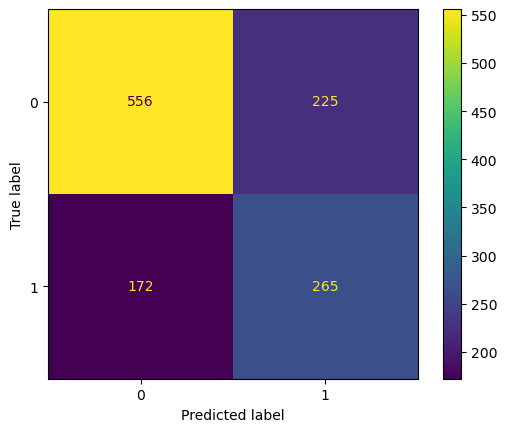

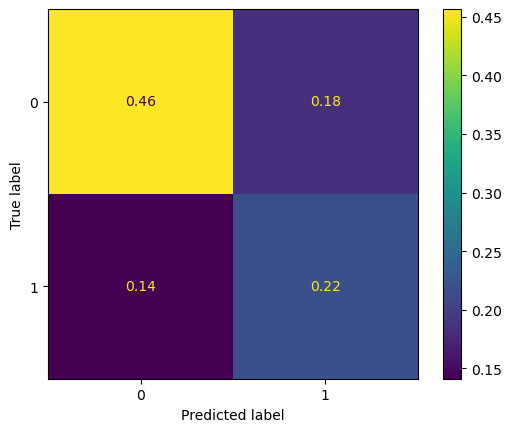

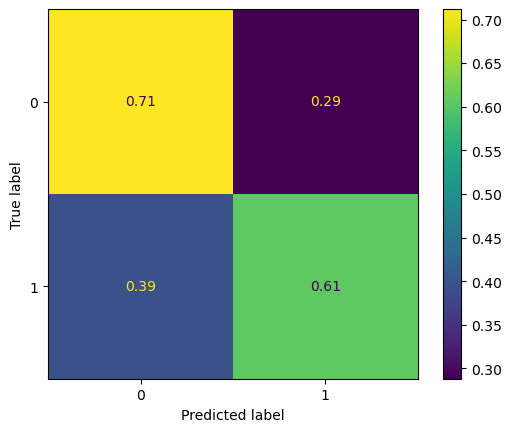



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       781
           1       0.54      0.61      0.57       437

    accuracy                           0.67      1218
   macro avg       0.65      0.66      0.65      1218
weighted avg       0.68      0.67      0.68      1218

ROC AUC: 0.7117012455427384


In [26]:
X3 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y3 = df_sin_outliers['two_year_recid']

X3_train, X3_test, y3_train, y3_test= train_test_split(X3, y3, test_size = 0.2, random_state = 69, stratify = y3)

model3 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight = 'balanced')

model3.fit(X3_train, y3_train)

y3_proba = model3.predict_proba(X3_test)[:,1]
y3_pred = (y3_proba >= 0.505).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y3_test, y3_pred))
print("\nReporte de clasificación:")
print(classification_report(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_proba))

coeficientes = pd.DataFrame({
    'Variable': X3.columns,
    'Coeficiente': model3.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_proba))

In [27]:

# model3 = BaggingClassifier(
#     estimator=LogisticRegression(penalty='l1', solver='liblinear'),
#     n_estimators=10
# )

# model3.fit(X3_train, y3_train, sample_weight=w3_train)

# y3_proba = model3.predict_proba(X3_test)[:,1]
# y3_pred = (y3_proba >= 0.37).astype(int)


# print("Matriz de confusión:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred))
# disp.plot()
# print("\n")
# disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "all"))
# disp.plot()
# disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "true"))
# disp.plot()
# plt.show()
# print("\n")
# print("Reporte de clasificación:")
# print(classification_report(y3_test, y3_pred))
# print("ROC AUC:", roc_auc_score(y3_test, y3_proba))


=== Raza: african-american ===


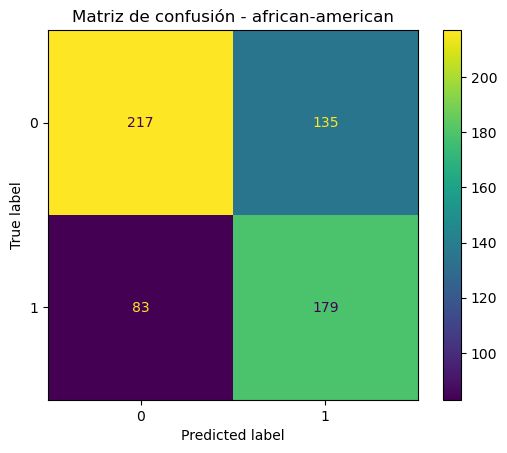

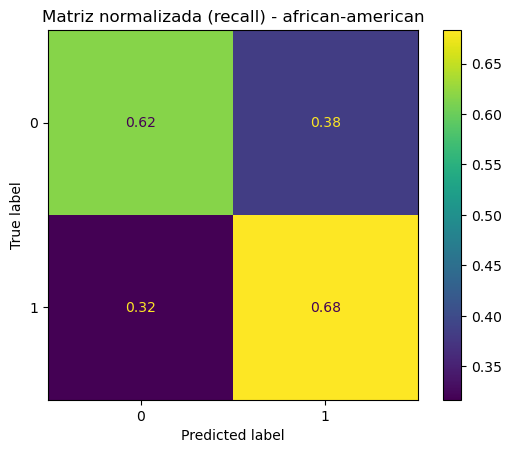


=== Raza: caucasian ===


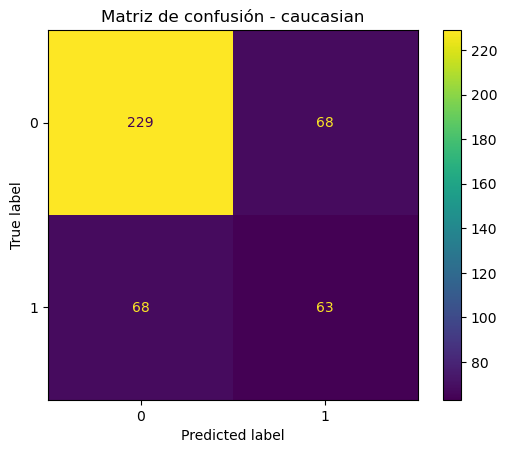

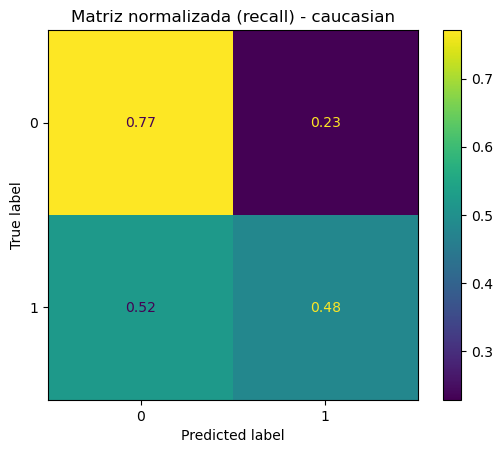


=== Raza: hispanic ===


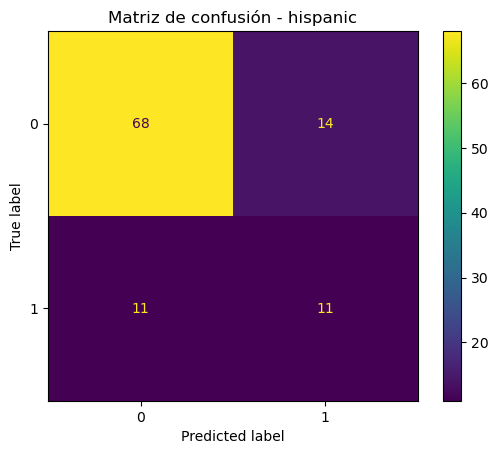

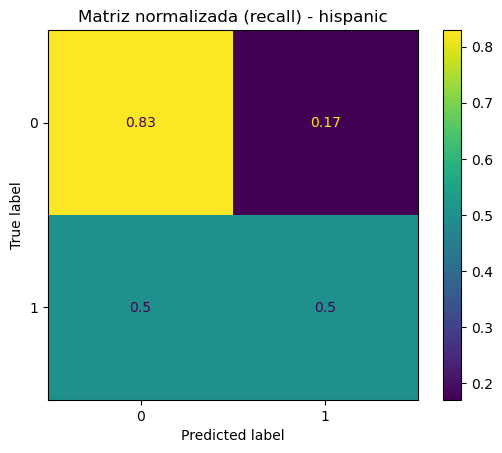


=== Raza: other ===


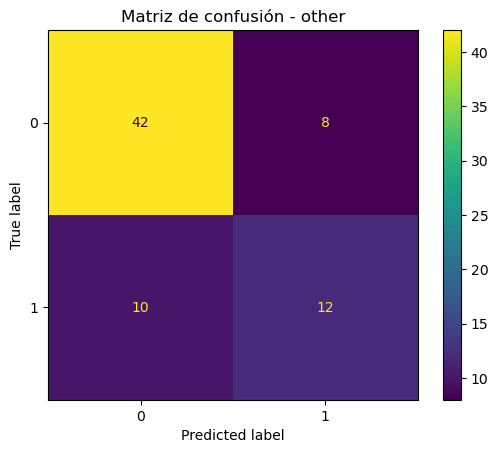

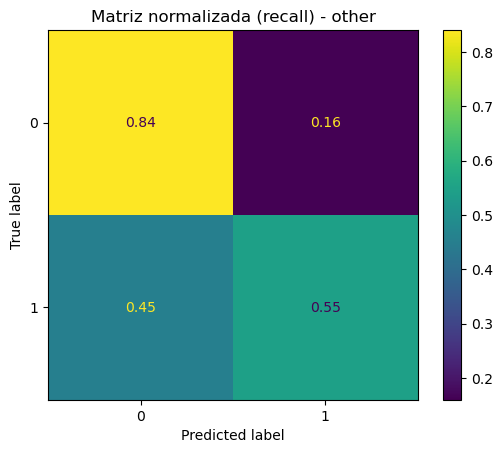

In [28]:
race_test = df_sin_outliers.loc[X3_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y3_test[idx]
    y_pred_r = y3_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

## Modelo v.1.4

In [29]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'priors_count', 'juv_priors_count', 'c_charge_degree', 'maritalstatus',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count',
       'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3', 'weight'],
      dtype='object')

In [30]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race',
       'priors_freq_3', 'priors_freq', 'sex', 'juv_priors_count','c_charge_degree','juv_fel_count','juv_misd_count','juv_other_count','maritalstatus_other','maritalstatus_separated','maritalstatus_significant other', 'priors_freq_2', 'weight']

In [31]:
# X4 = df_sin_outliers.drop(columns=lista_columnas_dropear)
# y4 = df_sin_outliers['two_year_recid']

# X4_train, X4_test, y4_train, y4_test, w4_train, w4_test = train_test_split(X4, y4, weights, test_size = 0.2, random_state = 69, stratify = y4)

# model4 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

# model4.fit(X4_train, y4_train, sample_weight= w4_train)

# y4_proba = model4.predict_proba(X4_test)[:,1]
# y4_pred = (y4_proba >= 0.37).astype(int)

# print("Matriz de confusión:")
# print(confusion_matrix(y4_test, y4_pred))
# print("\nReporte de clasificación:")
# print(classification_report(y4_test, y4_pred))
# print("ROC AUC:", roc_auc_score(y4_test, y4_proba))

# coeficientes = pd.DataFrame({
#     'Variable': X4.columns,
#     'Coeficiente': model4.coef_[0]
# })

# print(coeficientes)

In [32]:

# model4 = BaggingClassifier(
#     estimator=LogisticRegression(penalty='l1', solver='liblinear'),
#     n_estimators=10
# )

# model4.fit(X4_train, y4_train, sample_weight=w4_train)

# y4_proba = model4.predict_proba(X4_test)[:,1]
# y4_pred = (y4_proba >= 0.37).astype(int)


# print("Matriz de confusión:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y4_test, y4_pred))
# disp.plot()
# print("\n")
# disp = ConfusionMatrixDisplay(confusion_matrix(y4_test, y4_pred, normalize= "all"))
# disp.plot()
# disp = ConfusionMatrixDisplay(confusion_matrix(y4_test, y4_pred, normalize= "true"))
# disp.plot()
# plt.show()
# print("\n")
# print("Reporte de clasificación:")
# print(classification_report(y4_test, y4_pred))
# print("ROC AUC:", roc_auc_score(y4_test, y4_proba))

## Modelo v.2.0

In [33]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'priors_count', 'juv_priors_count', 'c_charge_degree', 'maritalstatus',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count',
       'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3', 'weight'],
      dtype='object')

In [34]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race',
       'priors_freq_3', 'priors_freq', 'priors_count', 'sex', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'weight', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other']

### Modelo MAYOR PRECISIÓN - sin RW

Matriz de confusión:
[[556 225]
 [172 265]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       781
           1       0.54      0.61      0.57       437

    accuracy                           0.67      1218
   macro avg       0.65      0.66      0.65      1218
weighted avg       0.68      0.67      0.68      1218

ROC AUC: 0.711666085550122
           Variable  Coeficiente
0               age    -0.017293
1  juv_priors_count     0.200187
2   c_charge_degree    -0.131310
3     priors_freq_2     5.822668
Matriz de confusión:




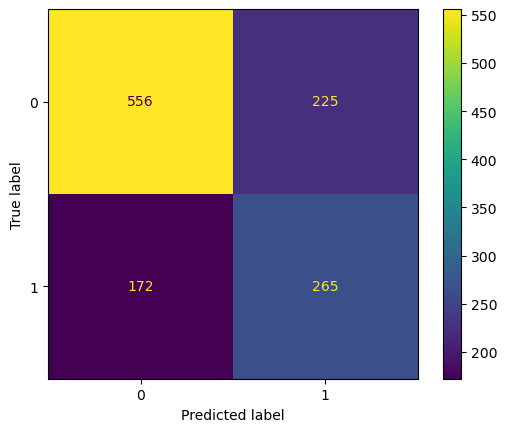

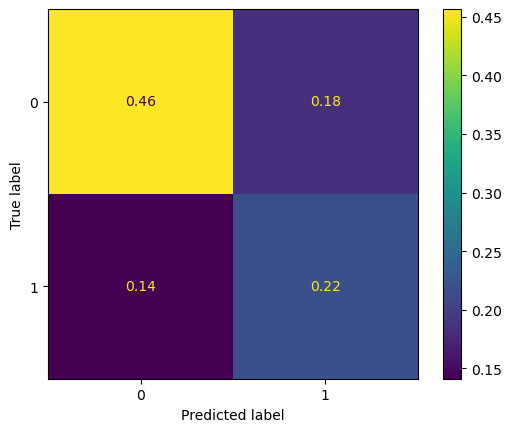

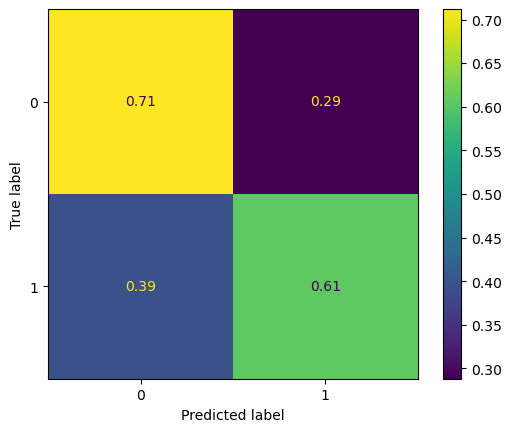



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       781
           1       0.54      0.61      0.57       437

    accuracy                           0.67      1218
   macro avg       0.65      0.66      0.65      1218
weighted avg       0.68      0.67      0.68      1218

ROC AUC: 0.711666085550122

=== Raza: african-american ===


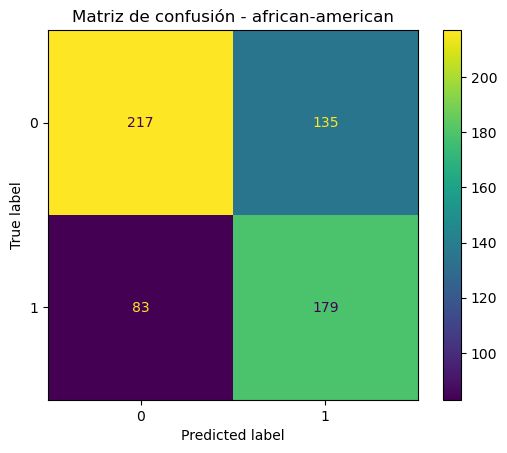

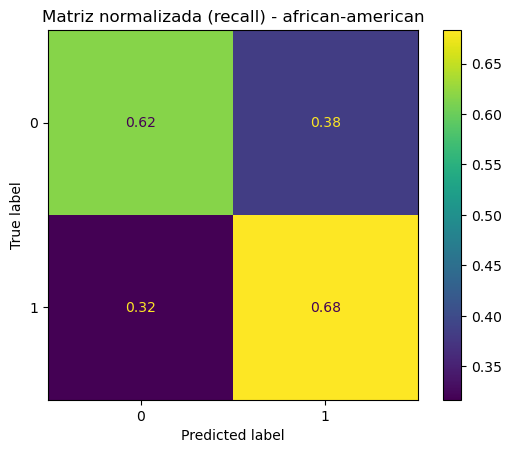


=== Raza: caucasian ===


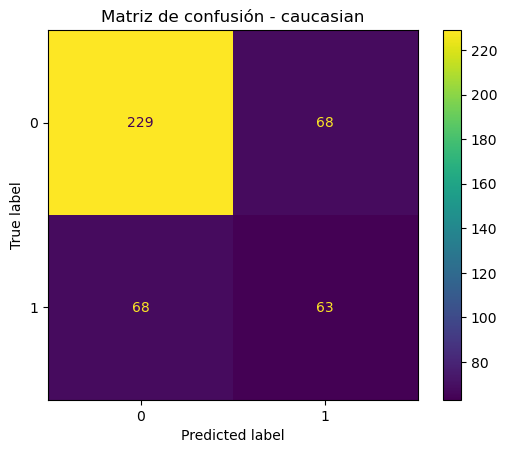

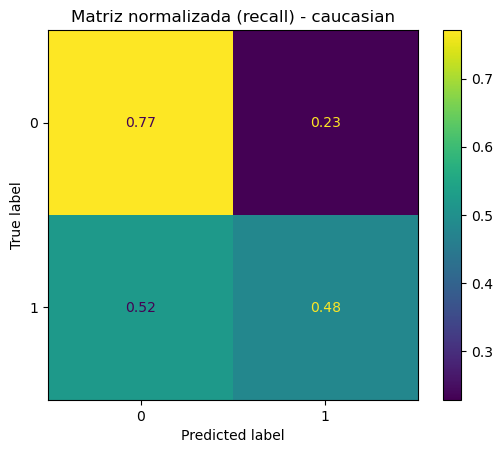


=== Raza: hispanic ===


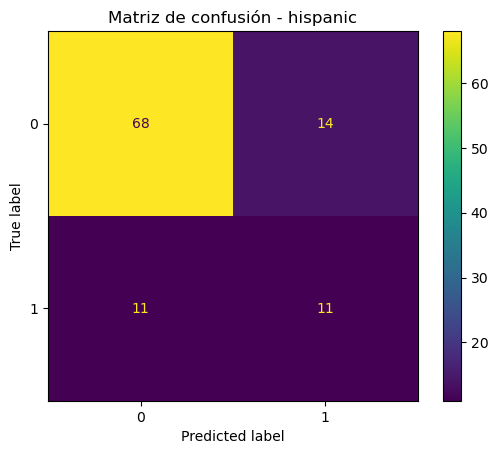

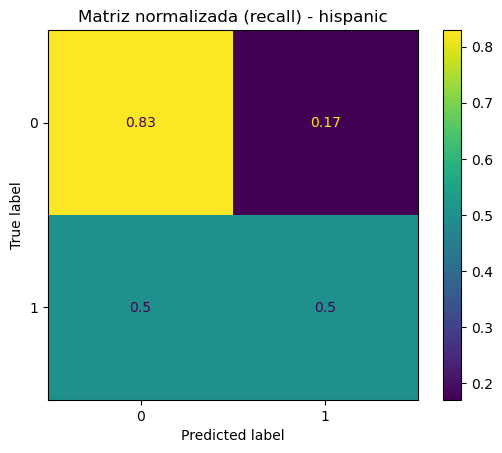


=== Raza: other ===


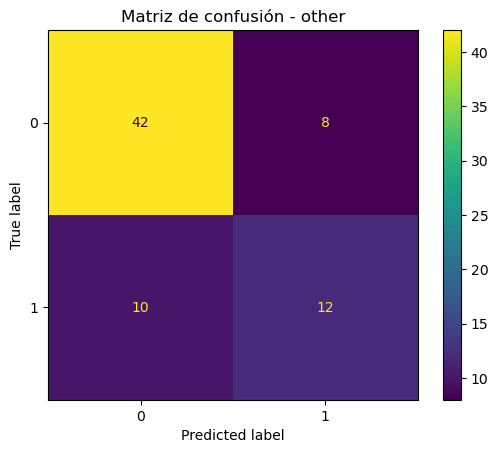

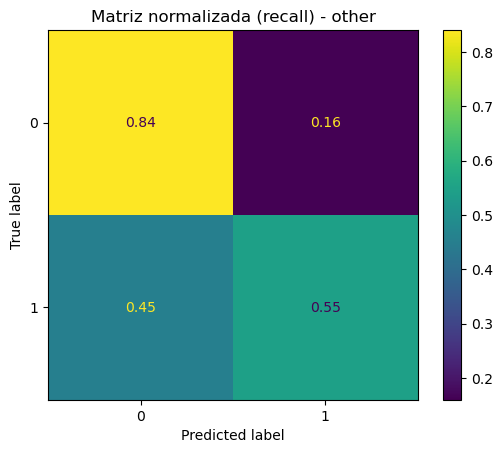

In [35]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.2, random_state = 69, stratify = y)

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight = 'balanced')

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.505).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

race_test = df_sin_outliers.loc[X_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

### Modelo MAYOR PRECISIÓN - Con RW

este es el bueno de los q conservan sesgo

Matriz de confusión:
[[560 221]
 [172 265]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74       781
           1       0.55      0.61      0.57       437

    accuracy                           0.68      1218
   macro avg       0.66      0.66      0.66      1218
weighted avg       0.69      0.68      0.68      1218

ROC AUC: 0.7126681453396894
           Variable  Coeficiente
0               age    -0.015018
1  juv_priors_count     0.198063
2   c_charge_degree    -0.176879
3     priors_freq_2     5.984059
Matriz de confusión:




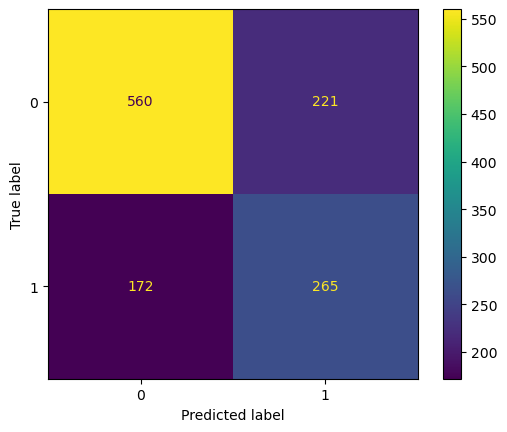

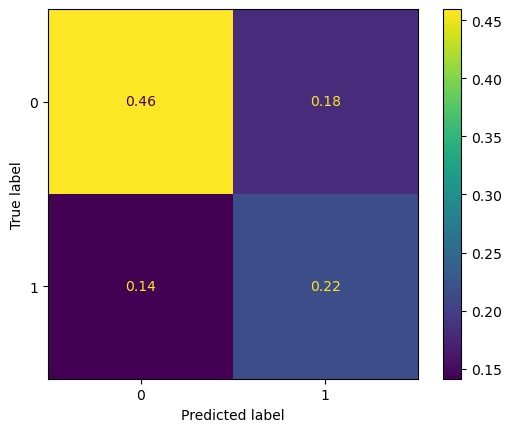

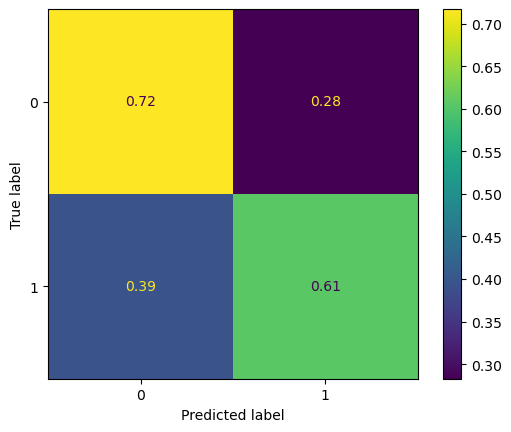



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74       781
           1       0.55      0.61      0.57       437

    accuracy                           0.68      1218
   macro avg       0.66      0.66      0.66      1218
weighted avg       0.69      0.68      0.68      1218

ROC AUC: 0.7126681453396894

=== Raza: african-american ===


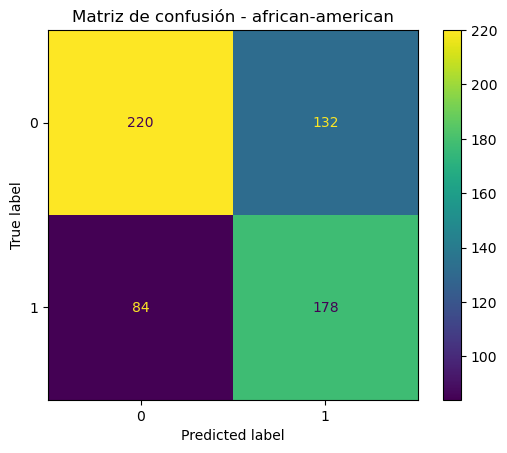

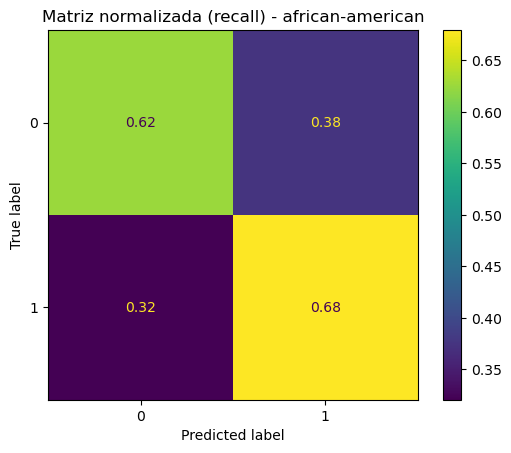


=== Raza: caucasian ===


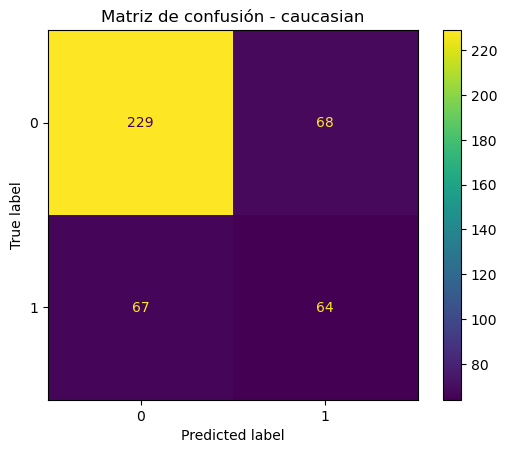

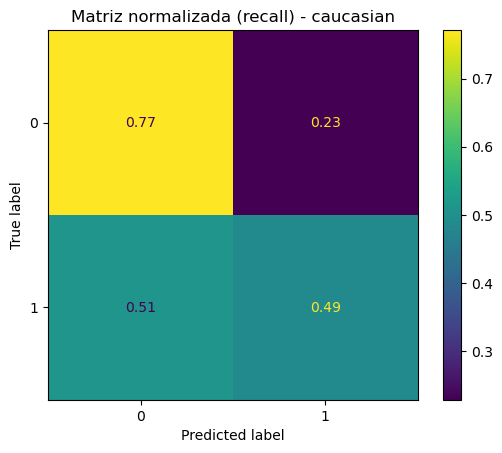


=== Raza: hispanic ===


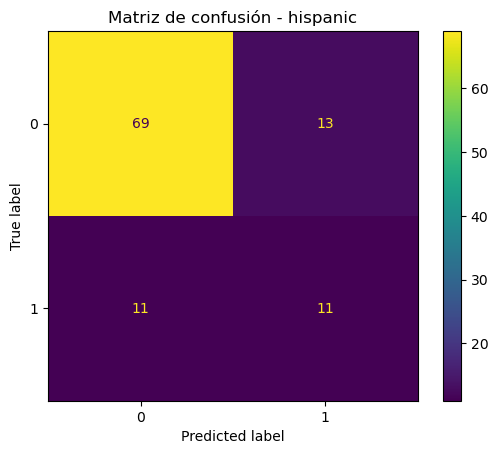

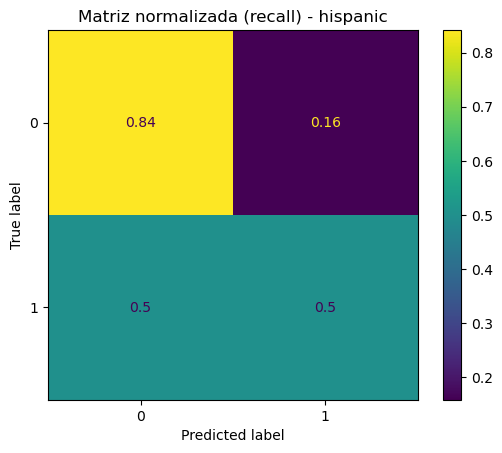


=== Raza: other ===


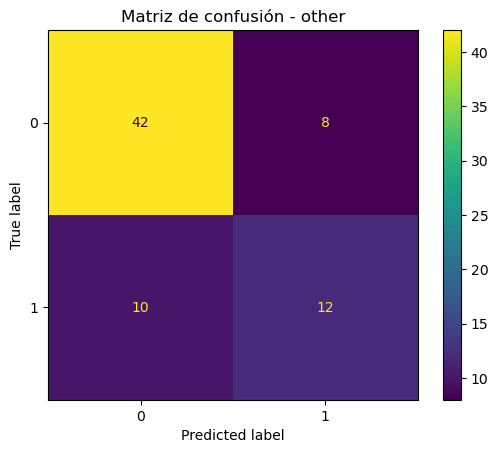

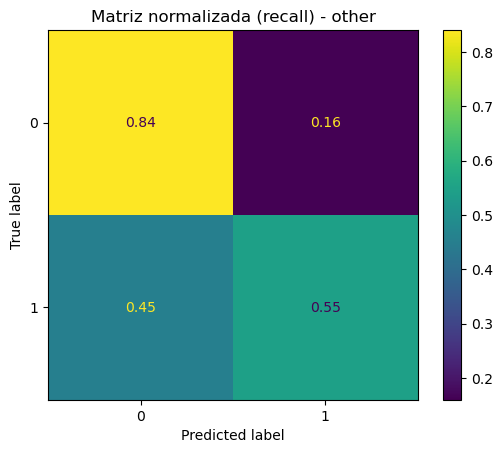

In [36]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']
race = df_sin_outliers['race']

X_train, X_test, y_train, y_test, race_train, race_test= train_test_split(X, y, race, test_size = 0.2, random_state = 69, stratify = y)

# Pesos por clase
conteo = y_train.value_counts()
total = len(y_train)

peso_0 = total / (2 * conteo[0])
peso_1 = total / (2 * conteo[1])

w_class = y_train.map({
    0: peso_0,
    1: peso_1
})

# Pesos por raza

dist_raza = race_train.value_counts(normalize=True)

peso_raza = {r: 1 / np.sqrt(dist_raza[r]) for r in dist_raza.index}

w_race = race_train.map(peso_raza)

# Peso final

w_train = w_class * w_race

# Modelo

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

model.fit(X_train, y_train, sample_weight=w_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

race_test = df_sin_outliers.loc[X_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

### Threshold por raza - con reweighting

Matriz de confusión:
[[506 275]
 [159 278]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.65      0.70       781
           1       0.50      0.64      0.56       437

    accuracy                           0.64      1218
   macro avg       0.63      0.64      0.63      1218
weighted avg       0.67      0.64      0.65      1218

ROC AUC: 0.7126740053384587

Coeficientes:
           Variable  Coeficiente
3     priors_freq_2     5.984119
1  juv_priors_count     0.198063
0               age    -0.015016
2   c_charge_degree    -0.176850


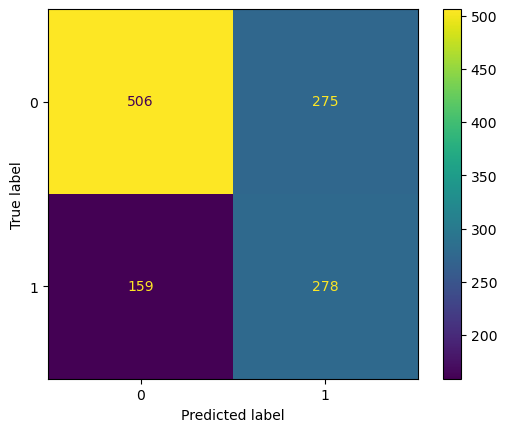

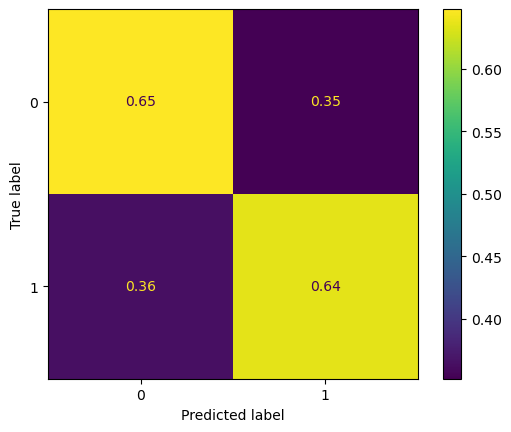


=== Raza: african-american ===


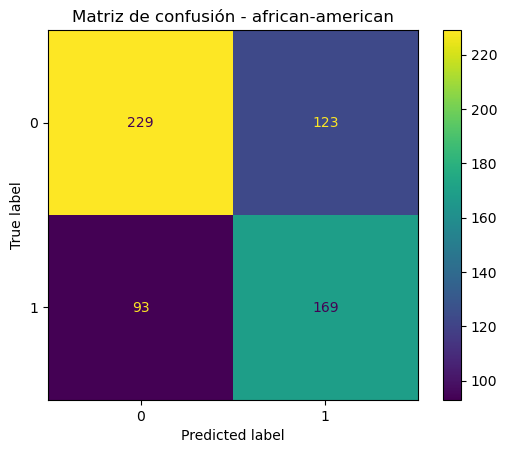

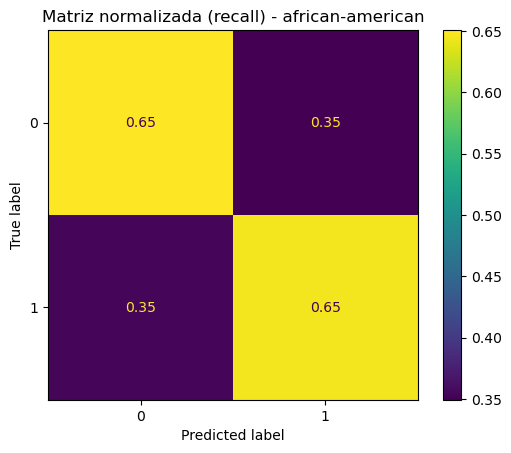

FPR: 0.220 | TPR: 0.727

=== Raza: caucasian ===


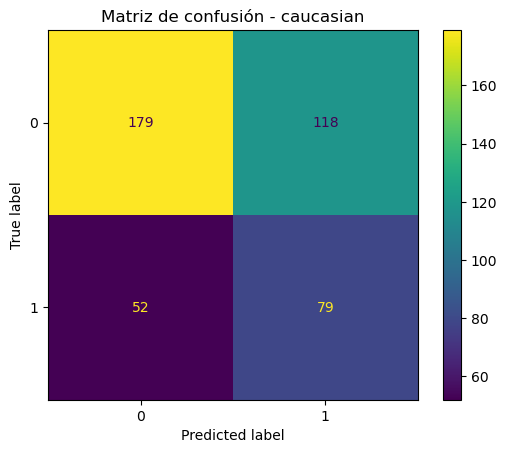

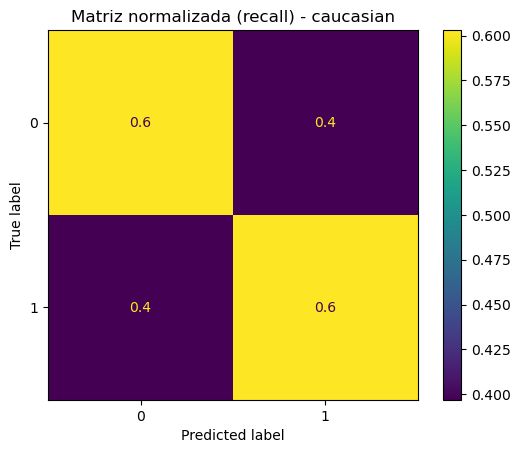

FPR: 0.220 | TPR: 0.727

=== Raza: hispanic ===


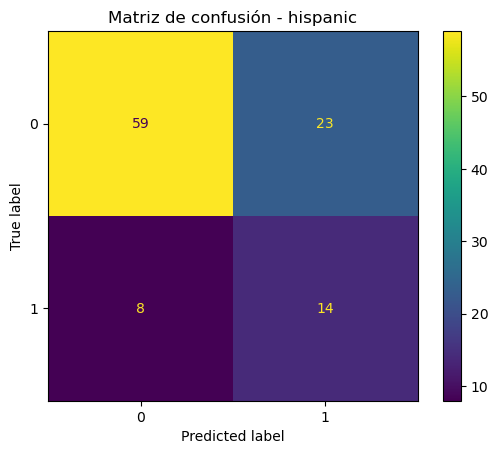

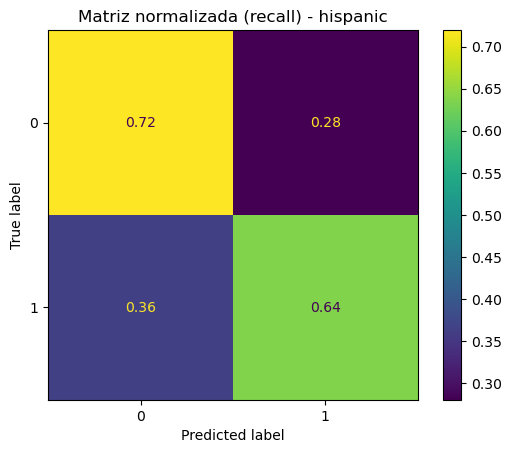

FPR: 0.220 | TPR: 0.727

=== Raza: other ===


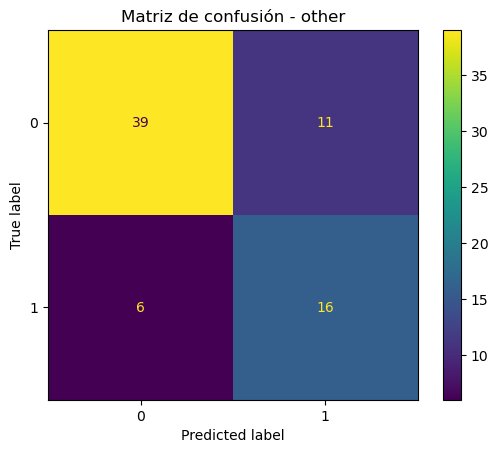

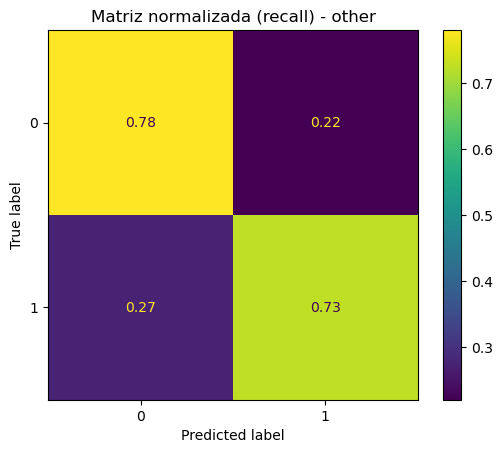

FPR: 0.220 | TPR: 0.727


In [57]:
# -------------------------
# 1. SPLIT
# -------------------------
X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race,
    test_size=0.2,
    random_state=69,
    stratify=y
)

# -------------------------
# 2. PESOS POR CLASE
# -------------------------
conteo = y_train.value_counts()
total = len(y_train)

peso_0 = total / (2 * conteo[0])
peso_1 = total / (2 * conteo[1])

w_class = y_train.map({0: peso_0, 1: peso_1})

# -------------------------
# 3. PESOS POR RAZA
# -------------------------
dist_raza = race_train.value_counts(normalize=True)

peso_raza = {r: 1 / np.sqrt(dist_raza[r]) for r in dist_raza.index}
w_race = race_train.map(peso_raza)

# -------------------------
# 4. PESO FINAL
# -------------------------
w_train = w_class * w_race

# -------------------------
# 5. MODELO
# -------------------------
model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')
model.fit(X_train, y_train, sample_weight=w_train)

# -------------------------
# 6. PROBABILIDADES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 7. DATAFRAME EVALUACIÓN
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 8. THRESHOLD POR RAZA
# -------------------------
thresholds = {
    'african-american': 0.52,
    'caucasian': 0.42,
    'hispanic': 0.44,
    'other': 0.45
}

def aplicar_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(aplicar_threshold, axis=1)
y_pred = df_eval['y_pred'].values

# -------------------------
# 9. RESULTADOS GLOBALES
# -------------------------
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 10. COEFICIENTES
# -------------------------
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print("\nCoeficientes:")
print(coeficientes.sort_values(by='Coeficiente', ascending=False))

# -------------------------
# 11. VISUALIZACIÓN GLOBAL
# -------------------------
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")

plt.show()

# -------------------------
# 12. FAIRNESS POR RAZA
# -------------------------
for raza in razas:
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

    # FPR
    fp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 0)).sum()
    tn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # TPR
    tp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 1)).sum()
    fn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

### Modelo v.2.0 - Adversarial

In [129]:
# # -------------------------
# # 1. COPIA DATASET
# # -------------------------
# df_aif = df_sin_outliers.copy()

# race_original = df_sin_outliers['race']

# # -------------------------
# # 2. CREAR VARIABLE BINARIA DE RAZA
# # (elige el criterio que quieras)
# # -------------------------
# df_aif['race_binary'] = (df_aif['race'] == 'african-american').astype(int)

# # -------------------------
# # 3. ELIMINAR race original
# # -------------------------
# df_aif = df_aif.drop(columns=['race'])

# # -------------------------
# # 4. CONVERTIR TODO A NUMÉRICO
# # -------------------------
# df_aif = pd.get_dummies(df_aif, drop_first=True)

# # -------------------------
# # 5. SPLIT
# # -------------------------
# df_train, df_test, race_train_orig, race_test_orig = train_test_split(
#     df_aif,
#     race_original,
#     test_size=0.2,
#     random_state=69,
#     stratify=df_aif['two_year_recid']
# )

# # -------------------------
# # 6. CREAR DATASETS AIF360
# # -------------------------
# train_dataset = BinaryLabelDataset(
#     df=df_train,
#     label_names=['two_year_recid'],
#     protected_attribute_names=['race_binary']
# )

# test_dataset = BinaryLabelDataset(
#     df=df_test,
#     label_names=['two_year_recid'],
#     protected_attribute_names=['race_binary']
# )

# # -------------------------
# # 7. DEFINIR GRUPOS
# # -------------------------
# privileged_groups = [{'race_binary': 1}]
# unprivileged_groups = [{'race_binary': 0}]

# # -------------------------
# # 8. MODELO ADVERSARIAL
# # -------------------------

# import sys
# import tensorflow.compat.v1 as tf

# sys.modules['tensorflow'] = tf
# tf.disable_eager_execution()

# tf.compat.v1.disable_eager_execution()

# tf.compat.v1.reset_default_graph()

# sess = tf.compat.v1.Session()

# model_adv = AdversarialDebiasing(
#     privileged_groups=privileged_groups,
#     unprivileged_groups=unprivileged_groups,
#     scope_name='debiasing',
#     debias=True,
#     sess=sess
# )

# model_adv.fit(train_dataset)

# # -------------------------
# # 9. PREDICCIÓN
# # -------------------------
# pred_dataset = model_adv.predict(test_dataset)

# y_pred_adv = pred_dataset.labels.ravel()
# y_true = test_dataset.labels.ravel()
# y_scores_adv = pred_dataset.scores.ravel()

# print("Matriz de confusión:")
# print(confusion_matrix(y_true, y_pred_adv))

# print("\nReporte de clasificación:")
# print(classification_report(y_true, y_pred_adv))

# print("ROC AUC:", roc_auc_score(y_true, y_scores_adv))

# df_eval = df_test.copy()
# df_eval['y_true'] = y_true
# df_eval['y_pred'] = y_pred_adv
# df_eval['race'] = race_test_orig.values

# # FPR por raza
# for r in df_eval['race'].unique():
#     grupo = df_eval[df_eval['race'] == r]
    
#     fp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 0)).sum()
#     tn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 0)).sum()
    
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
#     print(f"Race {r} - FPR: {fpr:.3f}")

In [130]:
!pip install fairlearn

### FairLearn

Distribuci贸n de probabilidades:
min: 0.0
max: 0.1799717459550827
mean: 0.014332725252580477

Threshold 0.2
[[781   0]
 [437   0]]

Threshold 0.3
[[781   0]
 [437   0]]

Threshold 0.4
[[781   0]
 [437   0]]

Threshold 0.5
[[781   0]
 [437   0]]
           Variable  Coeficiente
2   c_charge_degree     0.007732
0               age    -0.005370
1  juv_priors_count    -0.135983
3     priors_freq_2    -1.178835

Matriz de confusi贸n:


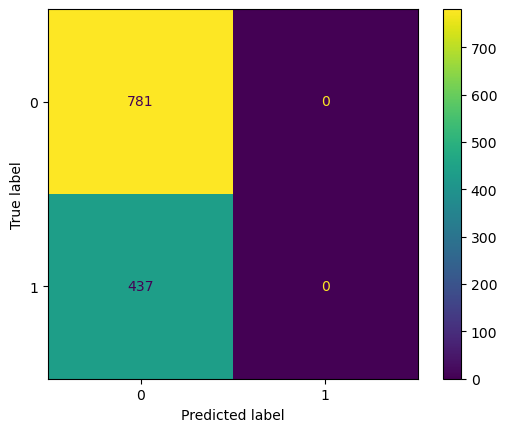


Reporte de clasificaci贸n:
              precision    recall  f1-score   support

           0       0.64      1.00      0.78       781
           1       0.00      0.00      0.00       437

    accuracy                           0.64      1218
   macro avg       0.32      0.50      0.39      1218
weighted avg       0.41      0.64      0.50      1218


=== Raza: african-american ===


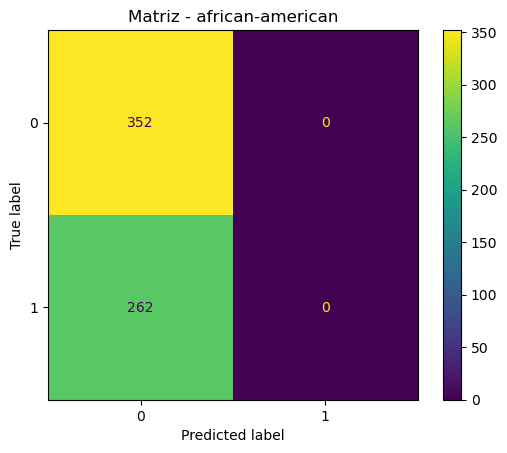

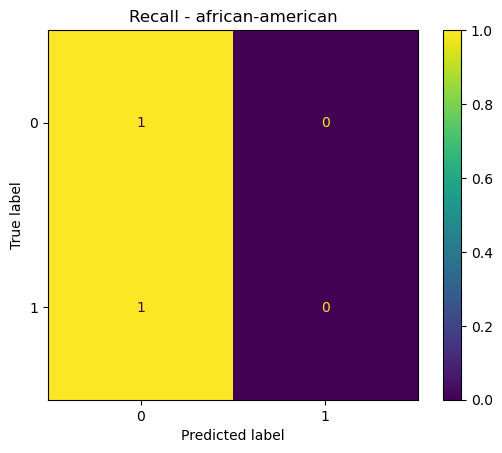


=== Raza: caucasian ===


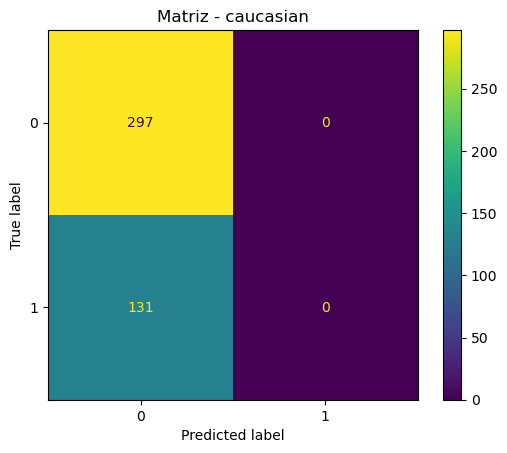

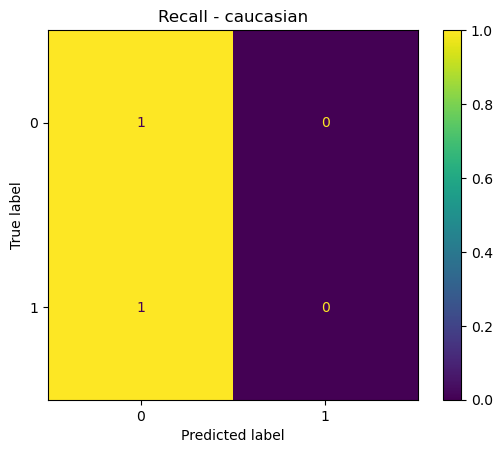


=== Raza: hispanic ===


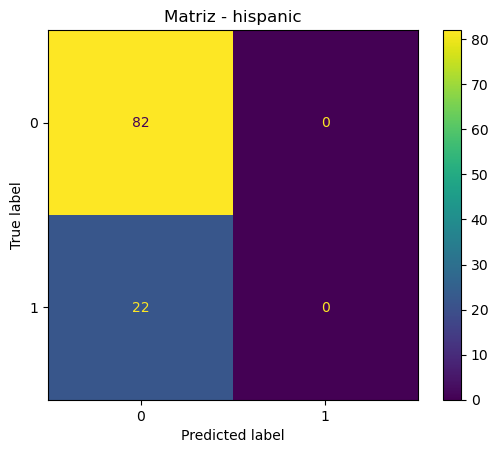

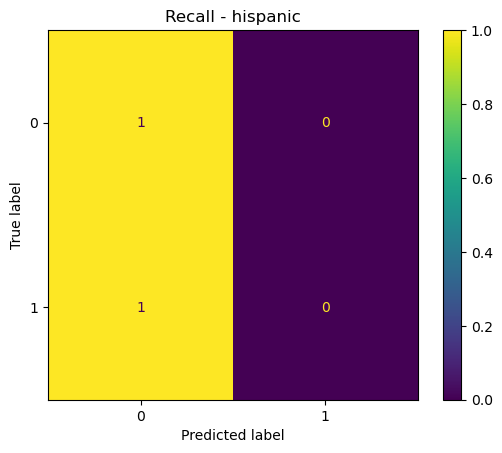


=== Raza: other ===


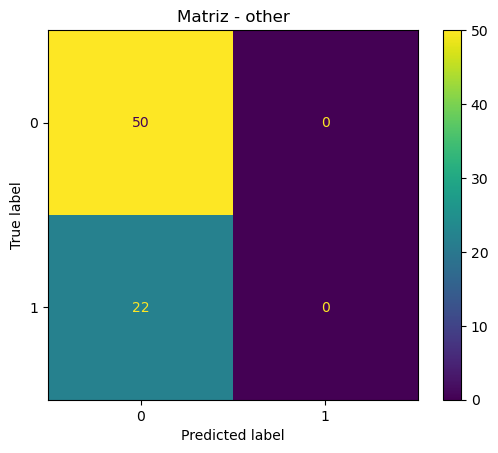

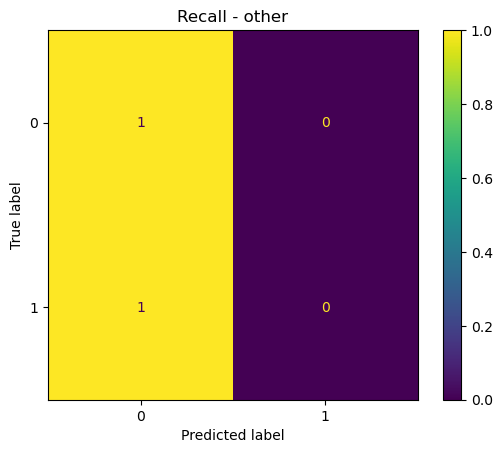

In [ ]:
# # -------------------------
# # 1. Datos
# # -------------------------
# X = df_sin_outliers.drop(columns=lista_columnas_dropear)
# y = df_sin_outliers['two_year_recid']
# race = df_sin_outliers['race']

# X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
#     X, y, race,
#     test_size=0.2,
#     random_state=69,
#     stratify=y
# )

# # -------------------------
# # 2. Modelo base (CORREGIDO)
# # -------------------------
# base_model = LogisticRegression(
#     max_iter=1000,
#     penalty='l2',   # 馃敟 cambio importante
#     solver='lbfgs'
# )

# # -------------------------
# # 3. Fairlearn
# # -------------------------
# fair_model = ExponentiatedGradient(
#     estimator=base_model,
#     constraints=DemographicParity(),
#     eps=0.1
# )

# fair_model.fit(X_train, y_train, sensitive_features=race_train)

# # -------------------------
# # 4. Probabilidades
# # -------------------------
# y_scores = fair_model._pmf_predict(X_test)[:, 1]

# # 馃攳 DEBUG CLAVE
# print("Distribuci贸n de probabilidades:")
# print("min:", y_scores.min())
# print("max:", y_scores.max())
# print("mean:", y_scores.mean())

# # -------------------------
# # 5. Threshold tuning
# # -------------------------
# for t in [0.2, 0.3, 0.4, 0.5]:
#     y_pred_tmp = (y_scores >= t).astype(int)
#     print(f"\nThreshold {t}")
#     print(confusion_matrix(y_test, y_pred_tmp))

# # 馃憠 usa uno razonable
# threshold = 0.3
# y_pred_fair = (y_scores >= threshold).astype(int)

# # -------------------------
# # 6. Coeficientes
# # -------------------------
# best_model = fair_model.predictors_[np.argmax(fair_model.weights_)]

# coeficientes = pd.DataFrame({
#     'Variable': X.columns,
#     'Coeficiente': best_model.coef_[0]
# })

# print(coeficientes.sort_values(by='Coeficiente', ascending=False))

# # -------------------------
# # 7. Evaluaci贸n global
# # -------------------------
# print("\nMatriz de confusi贸n:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_fair))
# disp.plot()

# plt.show()

# print("\nReporte de clasificaci贸n:")
# print(classification_report(y_test, y_pred_fair))

# # -------------------------
# # 8. Evaluaci贸n por raza
# # -------------------------
# y_pred_series = pd.Series(y_pred_fair, index=y_test.index)

# for raza in race_test.unique():
#     idx = race_test == raza
    
#     y_true_r = y_test.loc[idx]
#     y_pred_r = y_pred_series.loc[idx]
    
#     print(f"\n=== Raza: {raza} ===")
    
#     cm = confusion_matrix(y_true_r, y_pred_r)
#     ConfusionMatrixDisplay(cm).plot()
#     plt.title(f"Matriz - {raza}")
#     plt.show()
    
#     cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
#     ConfusionMatrixDisplay(cm_norm).plot()
#     plt.title(f"Recall - {raza}")
#     plt.show()

### Threshold por raza - sin reweighting

este es el bueno


Coeficientes:
           Variable  Coeficiente
3     priors_freq_2     5.825044
1  juv_priors_count     0.200236
0               age    -0.017264
2   c_charge_degree    -0.131225

Matriz de confusión:
[[505 276]
 [159 278]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.65      0.70       781
           1       0.50      0.64      0.56       437

    accuracy                           0.64      1218
   macro avg       0.63      0.64      0.63      1218
weighted avg       0.67      0.64      0.65      1218

ROC AUC: 0.7117188255390466


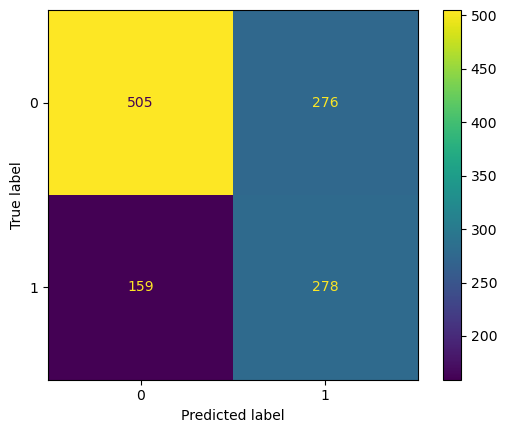

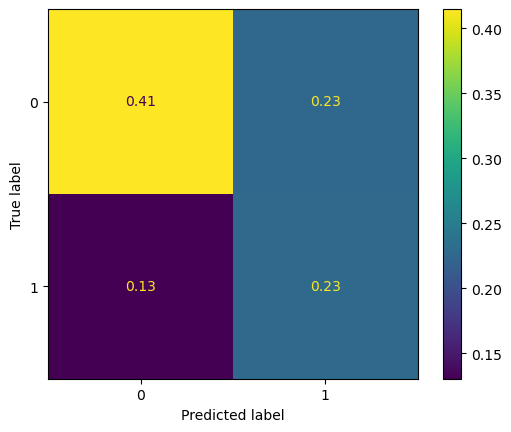

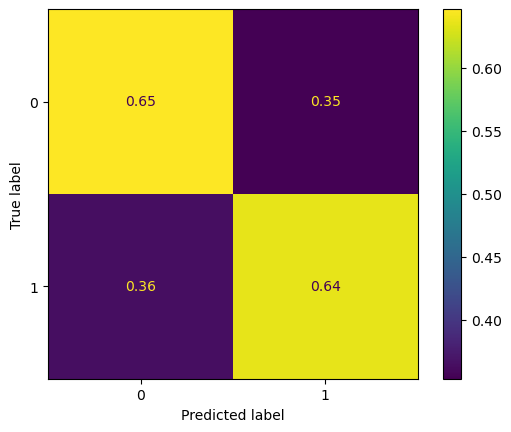


=== Raza: african-american ===


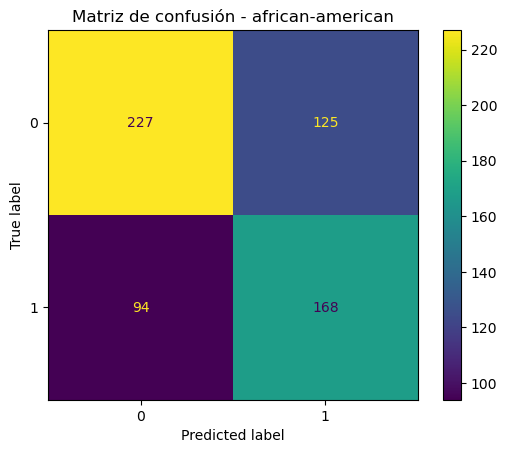

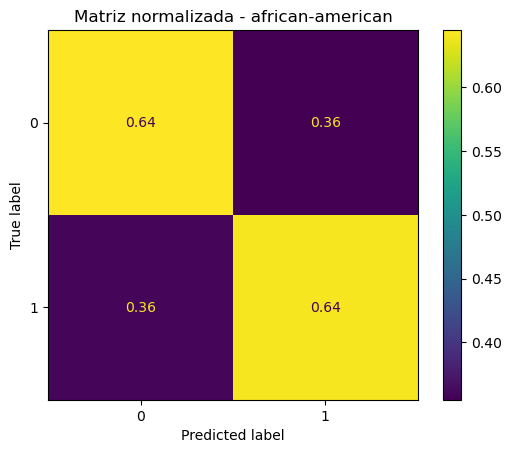

FPR: 0.355 | TPR: 0.641

=== Raza: caucasian ===


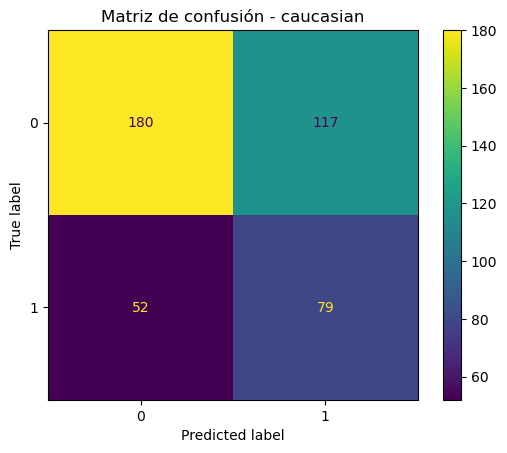

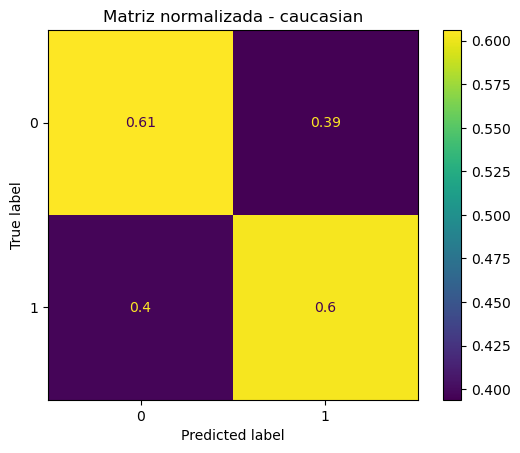

FPR: 0.394 | TPR: 0.603

=== Raza: hispanic ===


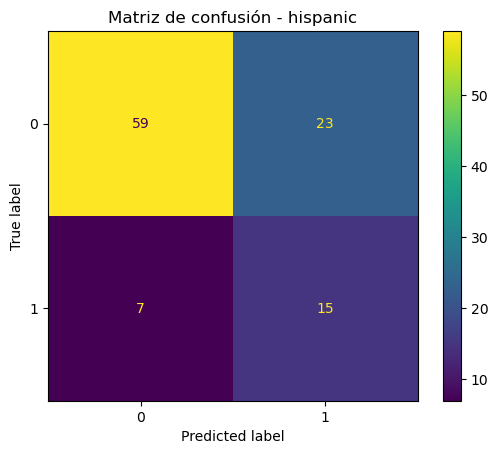

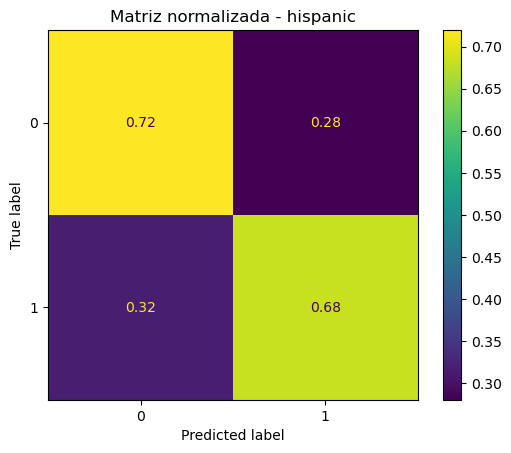

FPR: 0.280 | TPR: 0.682

=== Raza: other ===


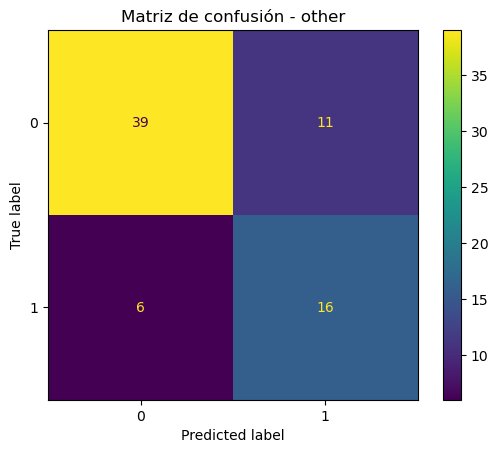

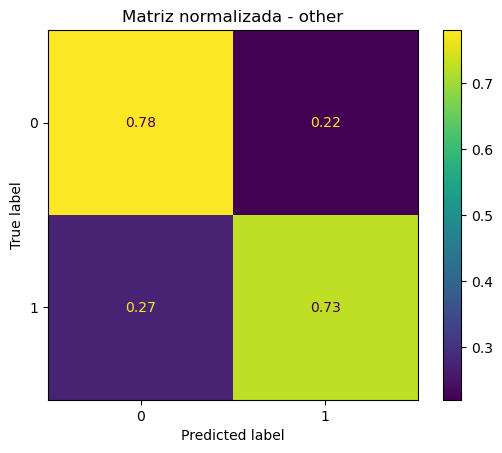

FPR: 0.220 | TPR: 0.727


In [200]:


# -------------------------
# 1. DATOS
# -------------------------
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODELO
# -------------------------
model = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILIDADES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 4. RAZA (para fairness)
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

# -------------------------
# 5. DATAFRAME EVALUACIÓN
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 6. THRESHOLD POR RAZA
# -------------------------
thresholds = {
    'african-american': 0.5199,
    'caucasian': 0.4299,
    'hispanic': 0.452,
    'other': 0.46
}

def aplicar_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(aplicar_threshold, axis=1)

y_pred = df_eval['y_pred'].values

# -------------------------
# 7. COEFICIENTES
# -------------------------
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print("\nCoeficientes:")
print(coeficientes.sort_values(by='Coeficiente', ascending=False))

# -------------------------
# 8. EVALUACIÓN GLOBAL
# -------------------------
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. VISUALIZACIÓN GLOBAL
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS POR RAZA
# -------------------------
razas = df_eval['race'].unique()

for raza in razas:
    grupo = df_eval[df_eval['race'] == raza]
    
    y_true_r = grupo['y_true']
    y_pred_r = grupo['y_pred']
    
    print(f"\n=== Raza: {raza} ===")
    
    # Matriz normal
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Matriz normalizada
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada - {raza}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

### Threshold por raza - sin rw sin cb


Coeficientes:
           Variable  Coeficiente
3     priors_freq_2     5.556951
1  juv_priors_count     0.193344
0               age    -0.018779
2   c_charge_degree    -0.132616

Matriz de confusión:
[[508 273]
 [162 275]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.65      0.70       781
           1       0.50      0.63      0.56       437

    accuracy                           0.64      1218
   macro avg       0.63      0.64      0.63      1218
weighted avg       0.67      0.64      0.65      1218

ROC AUC: 0.7105263157894738


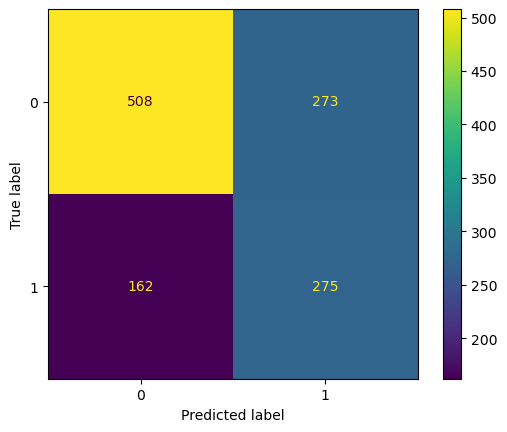

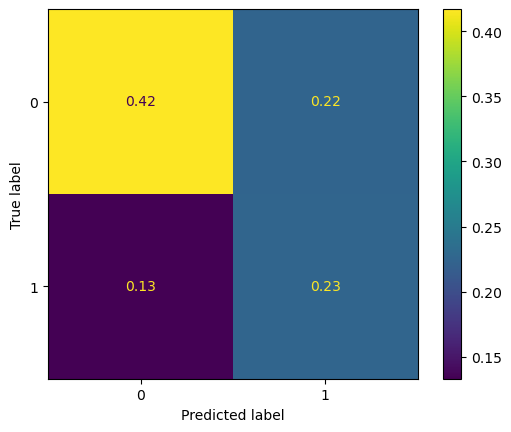

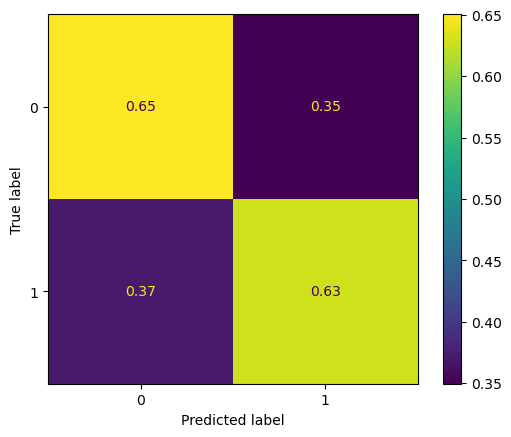


=== Raza: african-american ===


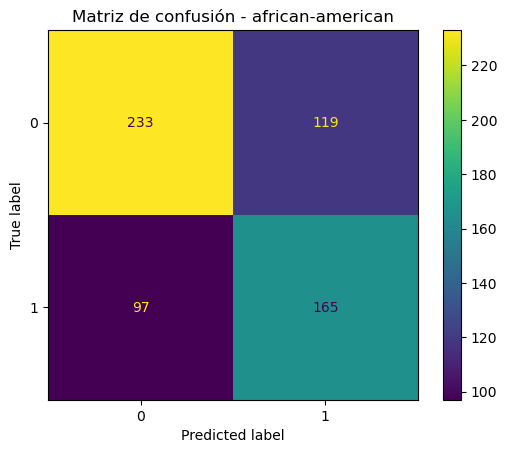

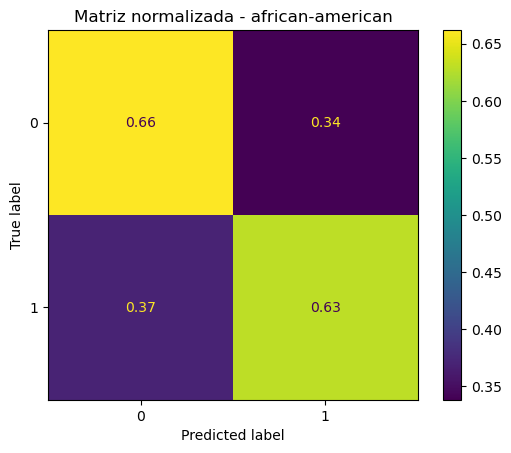

FPR: 0.338 | TPR: 0.630

=== Raza: caucasian ===


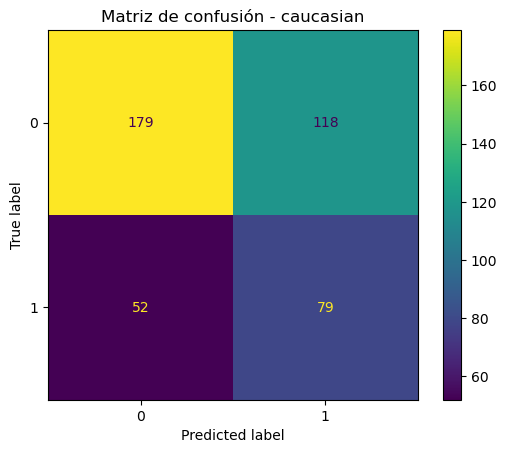

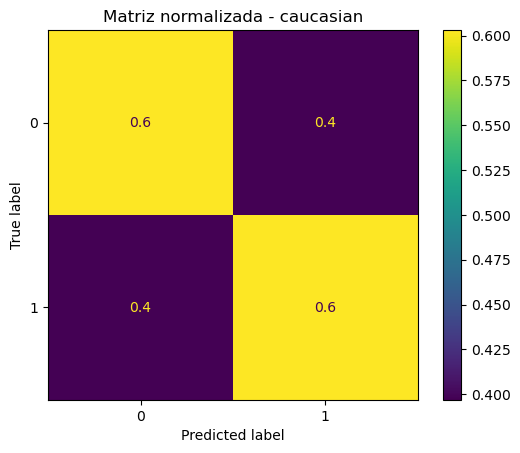

FPR: 0.397 | TPR: 0.603

=== Raza: hispanic ===


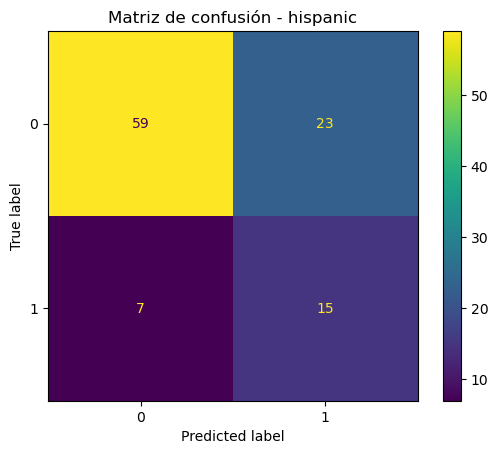

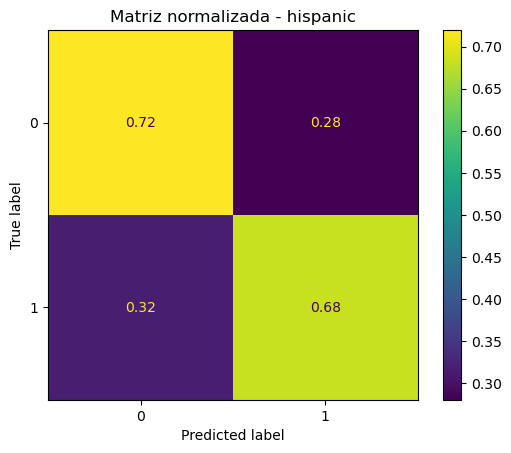

FPR: 0.280 | TPR: 0.682

=== Raza: other ===


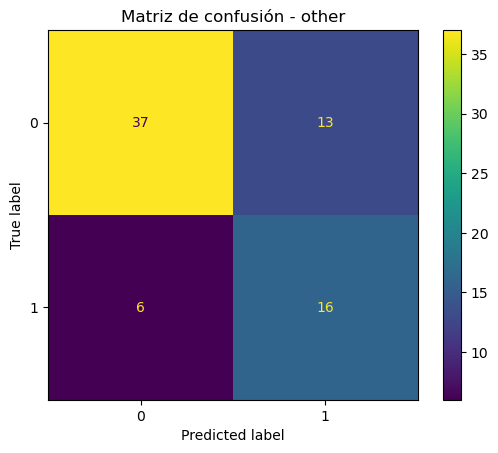

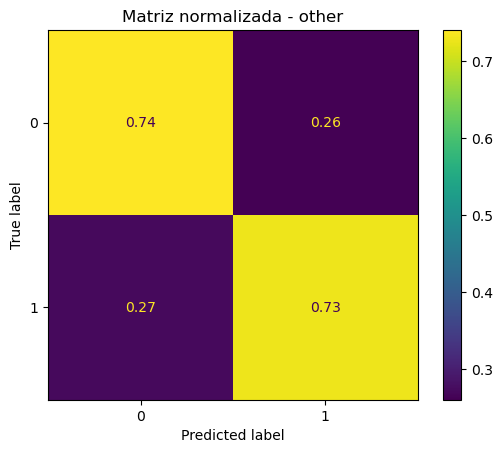

FPR: 0.260 | TPR: 0.727


In [196]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODELO
# -------------------------
model = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='liblinear'
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILIDADES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 4. RAZA (para fairness)
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

# -------------------------
# 5. DATAFRAME EVALUACIÓN
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 6. THRESHOLD POR RAZA
# -------------------------
thresholds = {
    'african-american': 0.39,
    'caucasian': 0.3,
    'hispanic': 0.323,
    'other': 0.325
}

def aplicar_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(aplicar_threshold, axis=1)

y_pred = df_eval['y_pred'].values

# -------------------------
# 7. COEFICIENTES
# -------------------------
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print("\nCoeficientes:")
print(coeficientes.sort_values(by='Coeficiente', ascending=False))

# -------------------------
# 8. EVALUACIÓN GLOBAL
# -------------------------
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. VISUALIZACIÓN GLOBAL
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS POR RAZA
# -------------------------
razas = df_eval['race'].unique()

for raza in razas:
    grupo = df_eval[df_eval['race'] == raza]
    
    y_true_r = grupo['y_true']
    y_pred_r = grupo['y_pred']
    
    print(f"\n=== Raza: {raza} ===")
    
    # Matriz normal
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Matriz normalizada
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada - {raza}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

### Modelo v.2.0 - Arbol de decisión

controlando por raza


Importancia de variables:
           Variable  Importancia
3     priors_freq_2     0.921858
0               age     0.064636
2   c_charge_degree     0.007577
1  juv_priors_count     0.005929

Matriz de confusión:
[[505 276]
 [161 276]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.65      0.70       781
           1       0.50      0.63      0.56       437

    accuracy                           0.64      1218
   macro avg       0.63      0.64      0.63      1218
weighted avg       0.67      0.64      0.65      1218

ROC AUC: 0.694294119198235


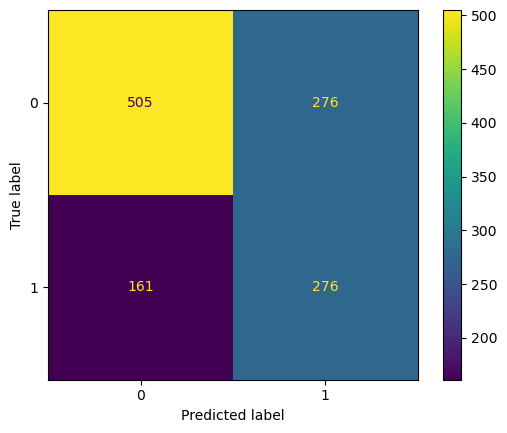

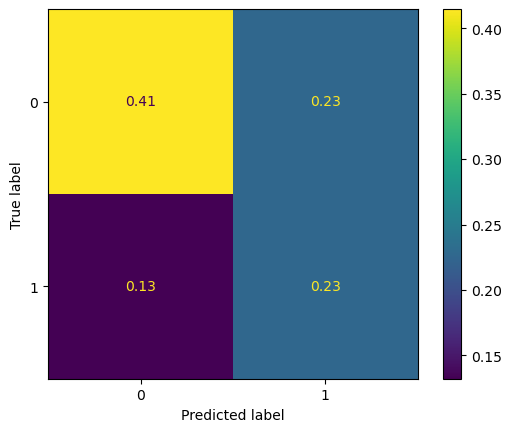

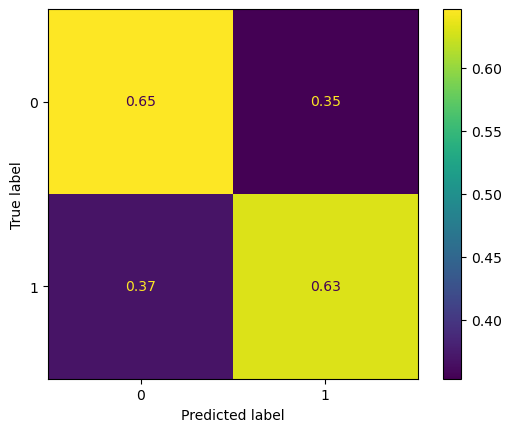


=== Raza: african-american ===


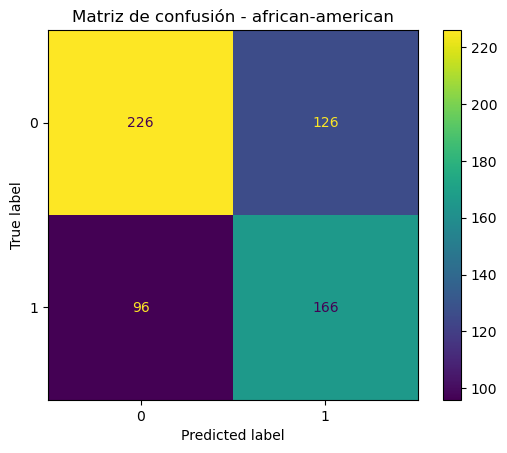

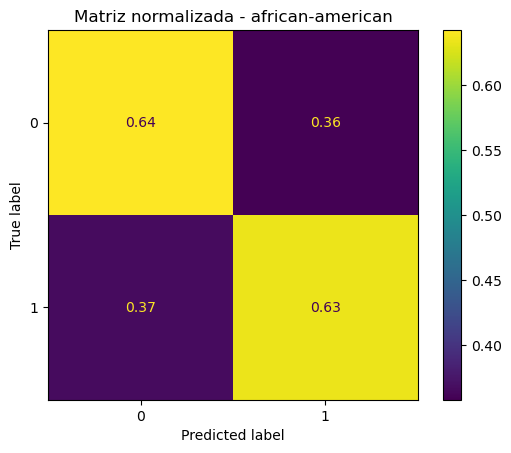

FPR: 0.358 | TPR: 0.634

=== Raza: caucasian ===


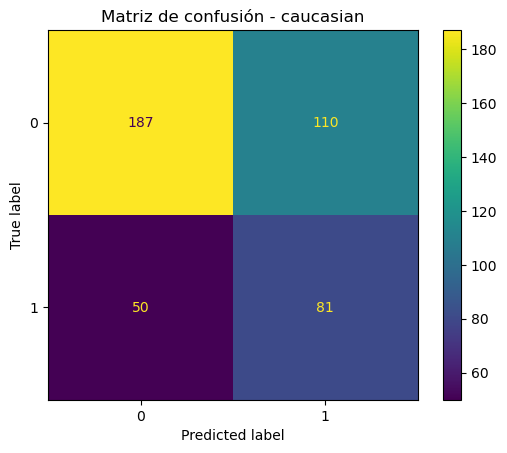

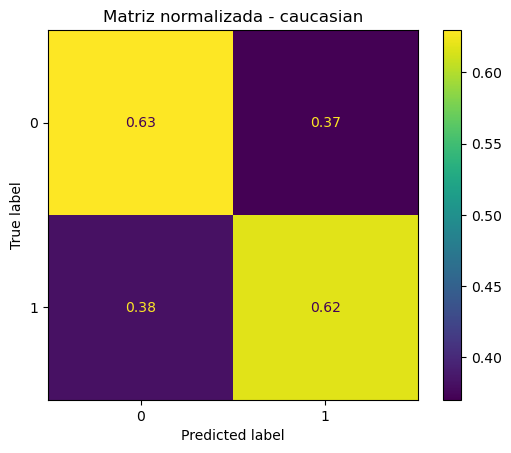

FPR: 0.370 | TPR: 0.618

=== Raza: hispanic ===


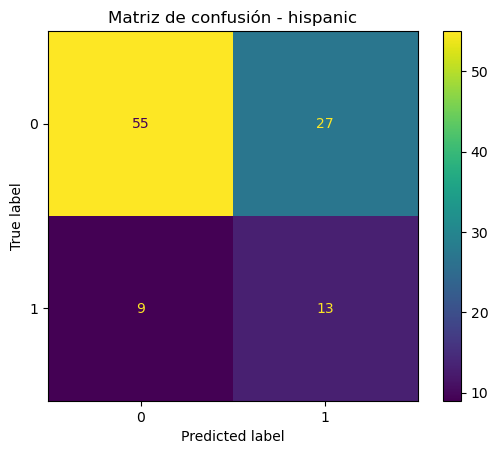

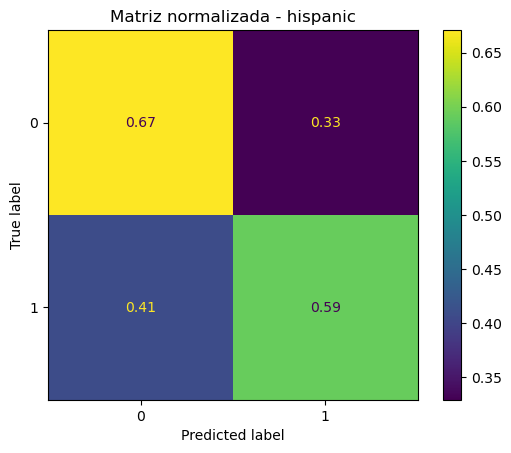

FPR: 0.329 | TPR: 0.591

=== Raza: other ===


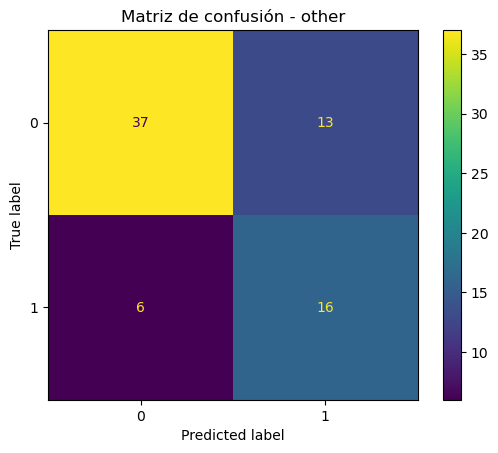

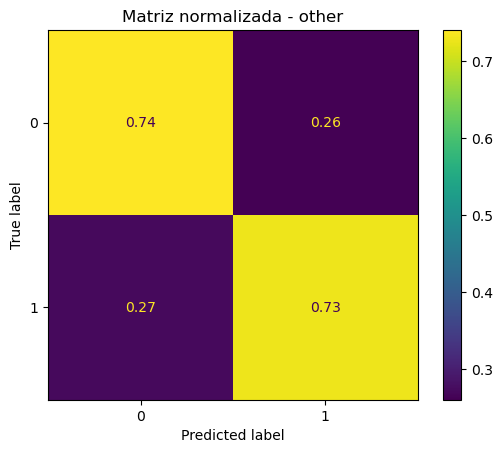

FPR: 0.260 | TPR: 0.727


In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------
# 1. DATOS
# -------------------------
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODELO (ÁRBOL)
# -------------------------
model = DecisionTreeClassifier(
    max_depth=5,              # 👈 importante para evitar overfitting
    min_samples_leaf=20,      # 👈 estabiliza el modelo
    class_weight='balanced',  # 👈 equivalente a lo que hacías antes
    random_state=69
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILIDADES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 4. RAZA
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

# -------------------------
# 5. DATAFRAME EVALUACIÓN
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 6. THRESHOLD POR RAZA
# -------------------------
thresholds = {
    'african-american': 0.5,
    'caucasian': 0.45,
    'hispanic': 0.3625,
    'other': 0.47
}

def aplicar_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(aplicar_threshold, axis=1)
y_pred = df_eval['y_pred'].values

# -------------------------
# 7. IMPORTANCIA VARIABLES
# -------------------------
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
})

print("\nImportancia de variables:")
print(importancias.sort_values(by='Importancia', ascending=False))

# -------------------------
# 8. EVALUACIÓN GLOBAL
# -------------------------
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. VISUALIZACIÓN GLOBAL
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS POR RAZA
# -------------------------
razas = df_eval['race'].unique()

for raza in razas:
    grupo = df_eval[df_eval['race'] == raza]
    
    y_true_r = grupo['y_true']
    y_pred_r = grupo['y_pred']
    
    print(f"\n=== Raza: {raza} ===")
    
    # Matriz normal
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Matriz normalizada
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada - {raza}")
    plt.show()
    
    # FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

Matriz de confusión:
[[442 339]
 [122 315]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.57      0.66       781
           1       0.48      0.72      0.58       437

    accuracy                           0.62      1218
   macro avg       0.63      0.64      0.62      1218
weighted avg       0.68      0.62      0.63      1218

ROC AUC: 0.7068638165585984

Importancia de variables:
           Variable  Importancia
3     priors_freq_2     0.912713
0               age     0.076437
2   c_charge_degree     0.007833
1  juv_priors_count     0.003016


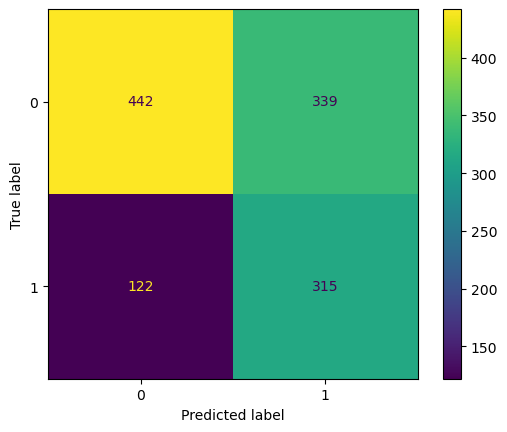

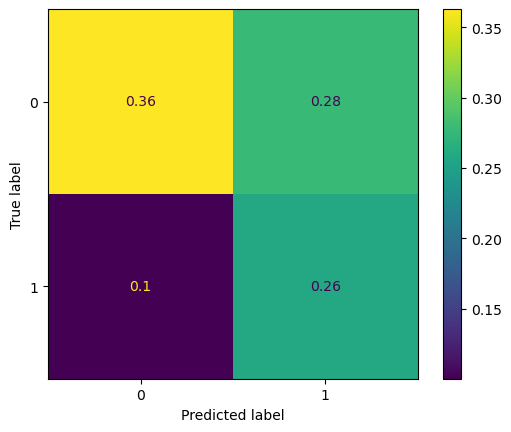

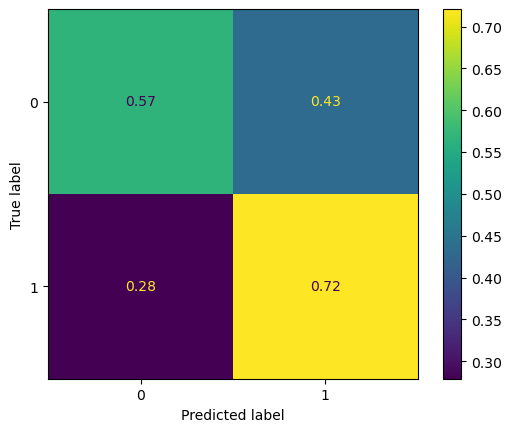


=== Raza: african-american ===


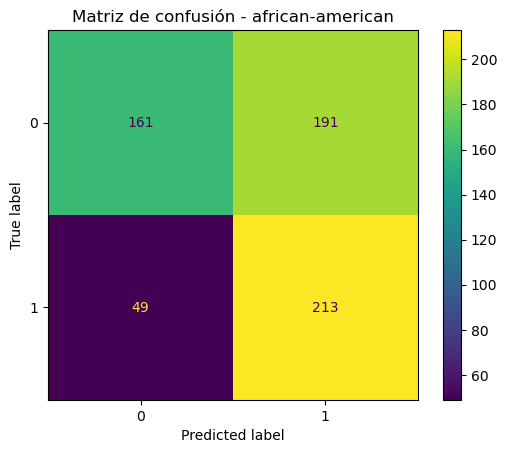

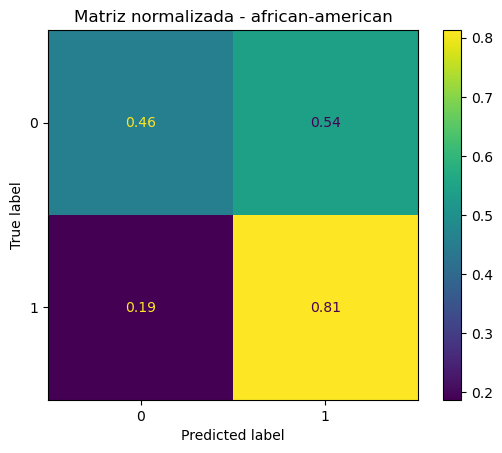

FPR: 0.543 | TPR: 0.813

=== Raza: caucasian ===


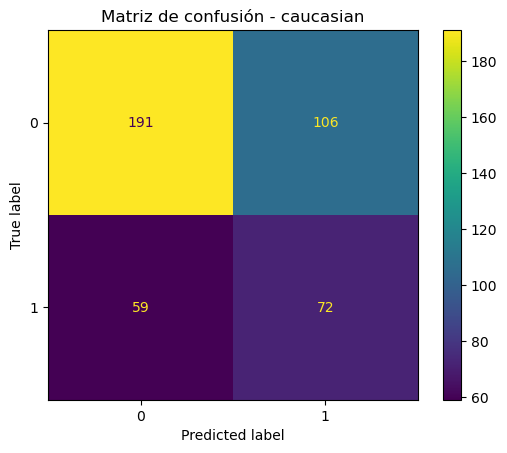

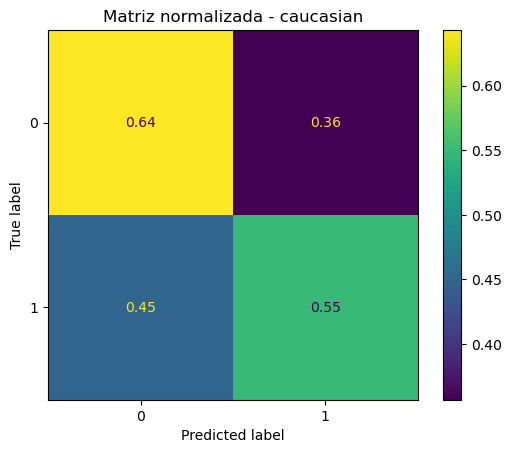

FPR: 0.357 | TPR: 0.550

=== Raza: hispanic ===


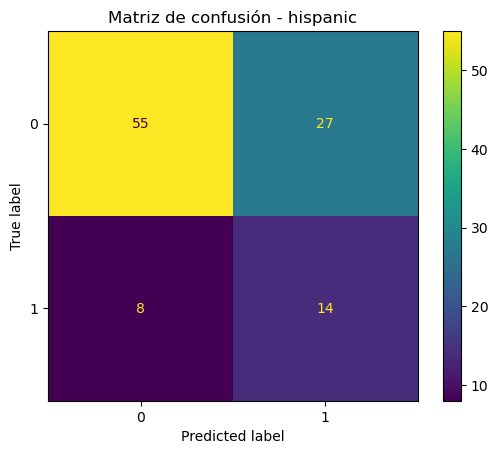

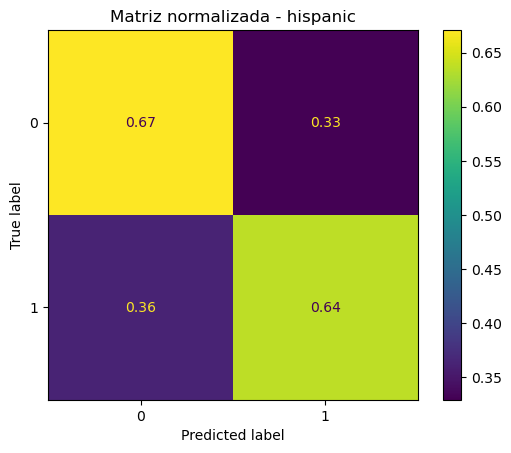

FPR: 0.329 | TPR: 0.636

=== Raza: other ===


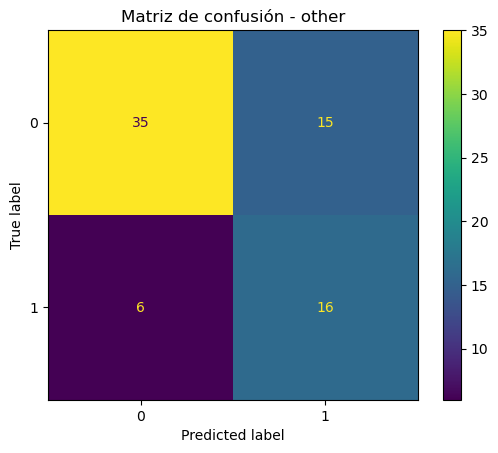

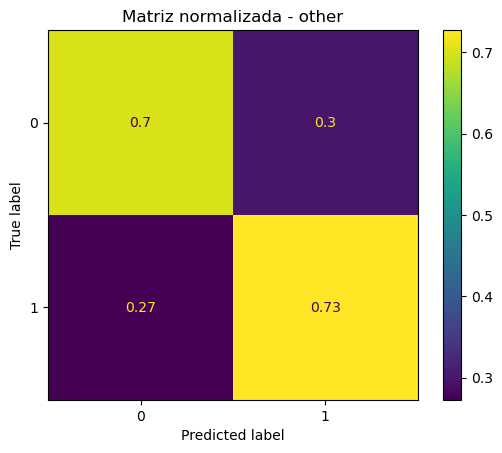

FPR: 0.300 | TPR: 0.727


In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------
# 1. DATOS
# -------------------------
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']
race = df_sin_outliers['race']

X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race,
    test_size=0.2,
    random_state=69,
    stratify=y
)

# -------------------------
# 2. PESOS POR CLASE
# -------------------------
conteo = y_train.value_counts()
total = len(y_train)

peso_0 = total / (2 * conteo[0])
peso_1 = total / (2 * conteo[1])

w_class = y_train.map({
    0: peso_0,
    1: peso_1
})

# -------------------------
# 3. PESOS POR RAZA
# -------------------------
dist_raza = race_train.value_counts(normalize=True)

peso_raza = {r: 1 / np.sqrt(dist_raza[r]) for r in dist_raza.index}

w_race = race_train.map(peso_raza)

# -------------------------
# 4. PESO FINAL
# -------------------------
w_train = w_class * w_race

# -------------------------
# 5. MODELO (ÁRBOL)
# -------------------------
model = DecisionTreeClassifier(
    max_depth=5,           # 👈 importante para estabilidad
    min_samples_leaf=20,   # 👈 evita overfitting
    random_state=69
)

model.fit(X_train, y_train, sample_weight=w_train)

# -------------------------
# 6. PREDICCIONES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# -------------------------
# 7. RESULTADOS GLOBALES
# -------------------------
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 8. IMPORTANCIA VARIABLES
# -------------------------
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
})

print("\nImportancia de variables:")
print(importancias.sort_values(by='Importancia', ascending=False))

# -------------------------
# 9. VISUALIZACIÓN GLOBAL
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS POR RAZA
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

for raza in race_test.unique():
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    # Matriz normal
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Matriz normalizada
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada - {raza}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

Matriz de confusión:
[[569 212]
 [191 246]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       781
           1       0.54      0.56      0.55       437

    accuracy                           0.67      1218
   macro avg       0.64      0.65      0.64      1218
weighted avg       0.67      0.67      0.67      1218

ROC AUC: 0.694294119198235

Importancia de variables:
           Variable  Importancia
3     priors_freq_2     0.921858
0               age     0.064636
2   c_charge_degree     0.007577
1  juv_priors_count     0.005929


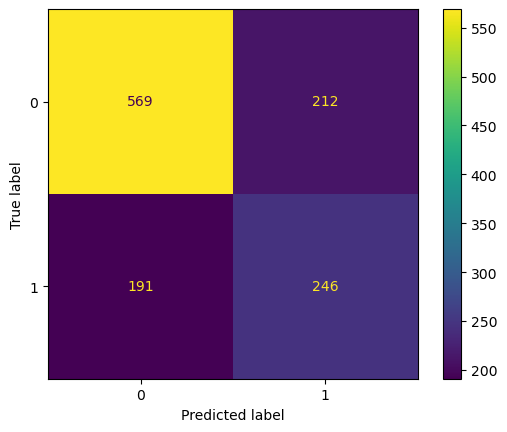

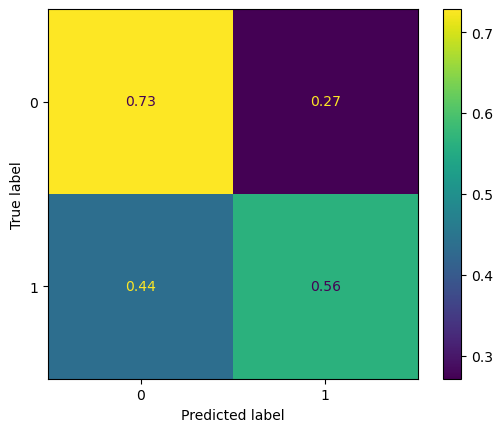


=== Raza: african-american ===


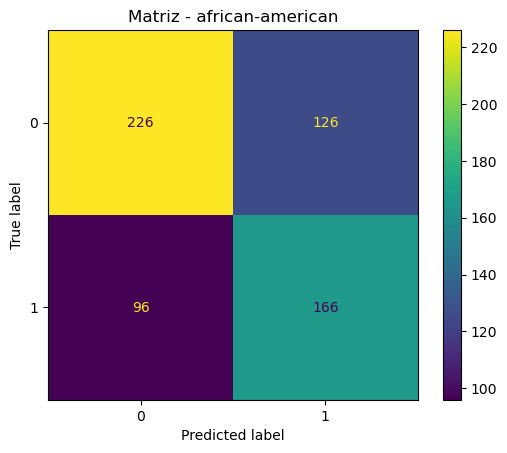

FPR: 0.358 | TPR: 0.634

=== Raza: caucasian ===


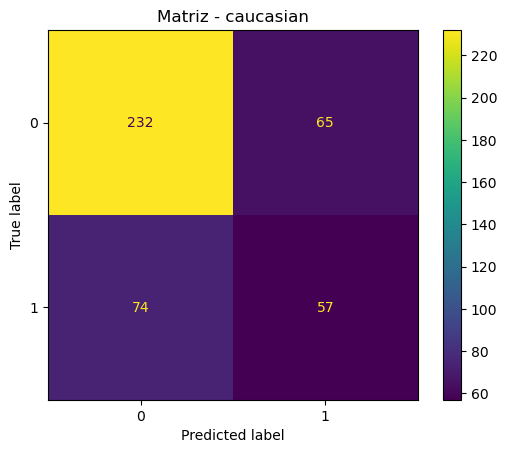

FPR: 0.219 | TPR: 0.435

=== Raza: hispanic ===


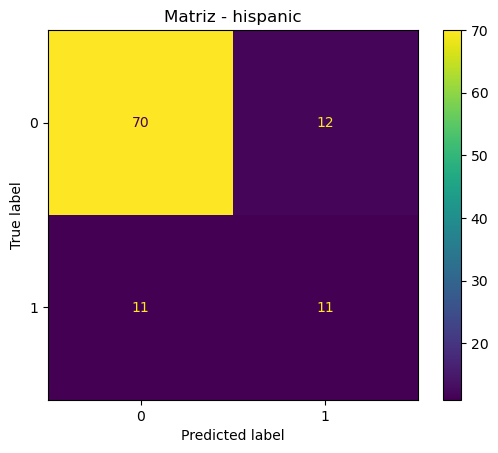

FPR: 0.146 | TPR: 0.500

=== Raza: other ===


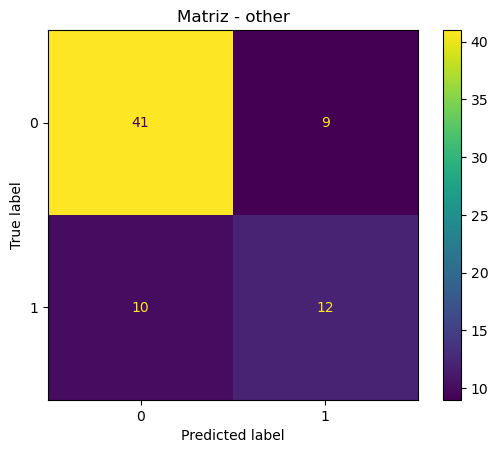

FPR: 0.180 | TPR: 0.545


In [218]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------
# 1. DATOS
# -------------------------
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODELO (ÁRBOL)
# -------------------------
model = DecisionTreeClassifier(
    max_depth=5,              # 👈 controla complejidad
    min_samples_leaf=20,      # 👈 evita ruido
    class_weight='balanced',  # 👈 balanceo de clases
    random_state=69
)

model.fit(X_train, y_train)

# -------------------------
# 3. PREDICCIONES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# -------------------------
# 4. RESULTADOS GLOBALES
# -------------------------
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 5. IMPORTANCIA VARIABLES
# -------------------------
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
})

print("\nImportancia de variables:")
print(importancias.sort_values(by='Importancia', ascending=False))

# -------------------------
# 6. VISUALIZACIÓN GLOBAL
# -------------------------
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")

plt.show()

# -------------------------
# 7. FAIRNESS POR RAZA
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'race': race_test
})

for raza, grupo in df_eval.groupby('race'):
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(grupo['y_true'], grupo['y_pred'])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz - {raza}")
    plt.show()
    
    # FPR
    fp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 0)).sum()
    tn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # TPR
    tp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 1)).sum()
    fn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")